**Note on numerical reproducibility.** The values reported in the manuscript
(mean deviation ≈25° / ≈16° / ≈3°; maximum tracking error 208.9°; minimum
single-joint deviation 0.07°) come from the original run of this notebook.
GPU simulation is not bit-wise deterministic, so re-running yields slightly
different values (e.g., 25.8° / 15.3° / 2.7°; maximum tracking error 205.6°;
minimum 0.06°; minimum vertical root velocity −1.94 m/s). The qualitative
result — terminal joint angles diverge substantially from the default posture
at both ablated and intact joints — is unchanged.

# G1版 感覚(深部感覚)喪失実験 — 準備段階

このノートブックは、H1研究(論文②、深部感覚喪失)と同じ設計思想を、G1に適用するための
ものです。**運動出力のablation(§3.1の`g1_single_neuron_ablation.ipynb`)とは異なり、
感覚のablationは「観測ベクトルの、特定の成分を書き換える」という、全く別の実装**に
なります。

**このノートブックは、まず「観測ベクトルの構造を、推測せず検証する」ことだけを目的と
した、準備段階です。** 検証結果を確認してから、実際のablation実装に進みます。


In [1]:
#mount
from google.colab import drive
drive.mount('/content/drive')

!cp -r "/content/drive/MyDrive/g1_cross_seed_logs/logs" /content/ && echo "復元しました" || echo "復元に失敗しました。パスを確認してください"

Mounted at /content/drive
復元しました


In [2]:
import os
print("logsフォルダが存在するか:", os.path.exists("logs"))
if os.path.exists("logs/rsl_rl/g1_velocity"):
    print("中身:", os.listdir("logs/rsl_rl/g1_velocity"))

logsフォルダが存在するか: True
中身: ['2026-07-20_12-36-23_seed1', '2026-07-20_07-27-58_seed1', '2026-07-21_17-06-40_seed7', '2026-07-21_14-56-27_seed6', '2026-07-20_01-50-54_seed3', '2026-07-20_02-11-51_seed4', '2026-07-20_16-57-27_seed3', '2026-07-20_11-25-33_seed1', '2026-07-20_14-46-30_seed2', '2026-07-20_12-09-08_seed2', '2026-07-21_19-17-45_seed8', '2026-07-20_21-21-30_seed5', '2026-07-20_01-30-11_seed2', '2026-07-20_01-08-28_seed1', '2026-07-20_11-03-36_seed1', '2026-07-20_19-09-05_seed4', '2026-07-20_02-32-52_seed5']


## 1. セットアップ

In [3]:
import os
os.environ["MUJOCO_GL"] = "egl"
os.environ["PYOPENGL_PLATFORM"] = ""
os.environ["WANDB_MODE"] = "offline"

%pip install -q "mjlab==1.2.0" "mujoco==3.5.0" "warp-lang==1.12.1" "numpy>=2.0,<2.3" scipy mediapy pandas

import torch
assert torch.cuda.is_available(), "GPU ランタイムに切り替えてください"
print("✅ install done:", torch.cuda.get_device_name(0))


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 107.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 114.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.4/136.4 MB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.2/84.2 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 79.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 754.2/754.2 kB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 601.7/601.7 kB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 750.4/750.4 kB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.9/216.9 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 103.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2

## 2. 観測ベクトル(actor, 99次元)の、内部構造を検証する(最重要)

**推測(base_lin_vel(3)+base_ang_vel(3)+gravity(3)+joint_pos(29)+joint_vel(29)+
actions(29)+command(3)=99)に頼らず、実際の環境の設定(cfg.observations)から、
各項目の名前・次元・並び順・開始インデックスを、直接確認します。**


In [4]:
import math
from mjlab.envs import ManagerBasedRlEnv
from mjlab.tasks.registry import load_env_cfg

TASK = "Mjlab-Velocity-Flat-Unitree-G1"
DEVICE = "cuda:0"
ENV_SEED = 100
RIGHT_FACING_YAW_RAD = -math.pi / 2

cfg = load_env_cfg(TASK)

# cfg.observations の中身を、まず一覧で確認する(events等と同じ手法)
print("cfg.observations の属性:", [a for a in dir(cfg.observations) if not a.startswith("_")])


cfg.observations の属性: ['clear', 'copy', 'fromkeys', 'get', 'items', 'keys', 'pop', 'popitem', 'setdefault', 'update', 'values']


In [5]:
# 上のセルの結果を見て、"actor"に相当する属性名を確認してから、その中身を見る
# (これまでの経験上、辞書(dict)形式である可能性が高いので、両対応で試す)
actor_group = cfg.observations.actor if hasattr(cfg.observations, "actor") else cfg.observations["actor"]

if hasattr(actor_group, "keys"):
    term_names = list(actor_group.keys())
    print("actor観測グループの、項目名(登場順):", term_names)
else:
    print("actor_group の型:", type(actor_group))
    print("属性:", [a for a in dir(actor_group) if not a.startswith("_")])


actor_group の型: <class 'mjlab.managers.observation_manager.ObservationGroupCfg'>
属性: ['concatenate_dim', 'concatenate_terms', 'enable_corruption', 'flatten_history_dim', 'history_length', 'nan_check_per_term', 'nan_policy', 'terms']


In [6]:
# 実際に環境を1つ作り、observation_managerから、各項目の"実際の次元数"を取得する。
# これにより、joint_pos・joint_velが、99次元の中の、何番目から何番目に対応するかを、
# 正確に(推測でなく)確定させる。
probe_cfg = load_env_cfg(TASK, play=True)
probe_cfg.scene.num_envs = 1
probe_cfg.seed = ENV_SEED
probe_env = ManagerBasedRlEnv(cfg=probe_cfg, device=DEVICE, render_mode=None)

om = probe_env.observation_manager
print("observation_manager の属性:", [a for a in dir(om) if not a.startswith("_")])


Setting seed: 100
Warp 1.12.1 initialized:
   CUDA Toolkit 12.9, Driver 13.0
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "Tesla T4" (15 GiB, sm_75, mempool enabled)
   Kernel cache:
     /root/.cache/warp/1.12.1
Warp DeprecationWarning: The symbol `warp.context.runtime` will soon be removed from the public API. It can still be accessed from `warp._src.context.runtime` but might be changed or removed without notice.
Module mujoco_warp._src.smooth f756680 load on device 'cuda:0' took 9721.33 ms  (compiled)
Module mujoco_warp._src.collision_driver 4d8b905 load on device 'cuda:0' took 167.36 ms  (compiled)
Module _nxn_broadphase__locals__kernel_e916423b e916423 load on device 'cuda:0' took 607.41 ms  (compiled)
Module _primitive_narrowphase__locals__primitive_narrowphase_f33437d9 f33437d load on device 'cuda:0' took 1309.11 ms  (compiled)
Module mujoco_warp._src.constraint 63c97cb load on device 'cuda:0' took 4446.31 ms  (compiled)
Module mujoco_warp._src.forward 7114b3d load 

In [7]:
# active_terms や group_obs_dim のような属性が見つかれば、それを使って、
# 各項目の名前と次元数を、正確に一覧表示する
try:
    print("active_terms:", om.active_terms)
except AttributeError:
    print("active_terms 属性はありません")

try:
    print("group_obs_dim:", om.group_obs_dim)
except AttributeError:
    print("group_obs_dim 属性はありません")

try:
    print("group_obs_term_dim:", om.group_obs_term_dim)
except AttributeError:
    print("group_obs_term_dim 属性はありません")


active_terms: {'actor': ['base_lin_vel', 'base_ang_vel', 'projected_gravity', 'joint_pos', 'joint_vel', 'actions', 'command'], 'critic': ['base_lin_vel', 'base_ang_vel', 'projected_gravity', 'joint_pos', 'joint_vel', 'actions', 'command', 'foot_height', 'foot_air_time', 'foot_contact', 'foot_contact_forces']}
group_obs_dim: {'actor': (99,), 'critic': (111,)}
group_obs_term_dim: {'actor': [(3,), (3,), (3,), (29,), (29,), (29,), (3,)], 'critic': [(3,), (3,), (3,), (29,), (29,), (29,), (3,), (2,), (2,), (2,), (6,)]}


In [8]:
# 上記のいずれかで、"actor"グループの、項目ごとの名前・次元数が取得できたら、
# それをもとに、joint_pos・joint_velの開始・終了インデックスを、正確に計算する。
# (このセルは、上のセルの出力を見てから、具体的な属性名に置き換えて実行してください)

# 例(active_terms が {"actor": [...], "critic": [...]} のような辞書の場合):
term_names_actor = om.active_terms["actor"] if hasattr(om, "active_terms") else None
term_dims_actor = om.group_obs_term_dim["actor"] if hasattr(om, "group_obs_term_dim") else None

if term_names_actor is not None and term_dims_actor is not None:
    print("actor観測グループの、項目ごとの内訳:")
    offset = 0
    for name, dim in zip(term_names_actor, term_dims_actor):
        # dimがタプル(例: (29,))の場合と、intの場合の両方に対応
        size = dim[0] if isinstance(dim, (tuple, list)) else dim
        print(f"  {name}: index [{offset}:{offset+size}]  (次元数={size})")
        offset += size
    print(f"\n合計次元数: {offset}(99と一致するはずです)")
else:
    print("自動計算に必要な属性が見つかりませんでした。上のセルの出力を確認し、")
    print("正しい属性名を教えてください。")

probe_env.close()
del probe_env
torch.cuda.empty_cache()


actor観測グループの、項目ごとの内訳:
  base_lin_vel: index [0:3]  (次元数=3)
  base_ang_vel: index [3:6]  (次元数=3)
  projected_gravity: index [6:9]  (次元数=3)
  joint_pos: index [9:38]  (次元数=29)
  joint_vel: index [38:67]  (次元数=29)
  actions: index [67:96]  (次元数=29)
  command: index [96:99]  (次元数=3)

合計次元数: 99(99と一致するはずです)


## 3. 感覚ablation関数の実装

**H1の`--blind-joints`と同じ発想**で、`policy(obs)`を呼び出す直前に、観測テンソル
(`obs["actor"]`)の中の、指定した関節の`joint_pos`・`joint_vel`成分を、直接操作します。
`zero`(完全喪失)・`scale`(段階的減衰)の、2モードに対応します(H1のスクリプトと同じ設計)。

**重要**: この操作は、observationの"入力"だけを書き換えるものであり、policyの重み・
運動出力(actor.mlp)には、一切手を加えません。**運動ablation(§3.1のノートブック)とは、
完全に独立した、別種の摂動**です。


In [9]:
# JOINT_NAMES を確定させる(§2の検証は「observationの並び順」の確認が目的だったため、
# 別途、関節名そのものの並び順も、実際の環境から取得しておく。
# g1_single_neuron_ablation.ipynb の §2 と、全く同じ手法・同じ結果になるはずです。
_probe_cfg_jn = load_env_cfg(TASK, play=True)
_probe_cfg_jn.scene.num_envs = 1
_probe_env_jn = ManagerBasedRlEnv(cfg=_probe_cfg_jn, device=DEVICE, render_mode=None)
JOINT_NAMES = list(_probe_env_jn.scene["robot"].joint_names)
assert len(JOINT_NAMES) == 29
print("JOINT_NAMES を確定しました(29関節):")
for i, name in enumerate(JOINT_NAMES):
    print(f"  [{i:2d}] {name}")
_probe_env_jn.close()
del _probe_env_jn
torch.cuda.empty_cache()



+---------------------------------+
|         Base Environment        |
+------------------------+--------+
| Property               | Value  |
+------------------------+--------+
| Number of environments | 1      |
| Environment device     | cuda:0 |
| Environment seed       | None   |
| Physics step-size      | 0.005  |
| Environment step-size  | 0.02   |
+------------------------+--------+

[INFO] <EventManager> contains 2 active terms.
+-------------------------------------+
| Active Event Terms in Mode: 'reset' |
+--------+----------------------------+
| Index  | Name                       |
+--------+----------------------------+
|   0    | reset_base                 |
|   1    | reset_robot_joints         |
|   2    | randomize_terrain          |
+--------+----------------------------+
+---------------------------------------+
| Active Event Terms in Mode: 'startup' |
+-----------+---------------------------+
|   Index   | Name                      |
+-----------+--------------

In [10]:
import glob
import re
import os
import pandas as pd
from pathlib import Path
from dataclasses import asdict
from mjlab.rl import MjlabOnPolicyRunner, RslRlVecEnvWrapper
from mjlab.tasks.registry import load_rl_cfg

JOINT_POS_START = 9
JOINT_VEL_START = 38


def blind_observation(obs, blind_joint_indices, mode="zero", level=0.0):
    """obs(TensorDict)の"actor"テンソルの、指定した関節のjoint_pos/joint_velを操作する。
    mode="zero": 完全に0にする(H1の--degradation-mode zero に相当)
    mode="scale": level倍する(level=1.0で正常、0.0で完全喪失。H1の--degradation-mode scale に相当)
    """
    obs = obs.clone()
    actor_obs = obs["actor"].clone()
    for idx in blind_joint_indices:
        pos_col = JOINT_POS_START + idx
        vel_col = JOINT_VEL_START + idx
        if mode == "zero":
            actor_obs[:, pos_col] = 0.0
            actor_obs[:, vel_col] = 0.0
        elif mode == "scale":
            actor_obs[:, pos_col] = actor_obs[:, pos_col] * level
            actor_obs[:, vel_col] = actor_obs[:, vel_col] * level
        else:
            raise ValueError(f"未知のmode: {mode}")
    obs["actor"] = actor_obs
    return obs


def run_sensory_ablation_rollout(checkpoint_path, blind_joint_indices, forward_speed_mps,
                                    mode="zero", level=0.0, steps=250, env_seed=ENV_SEED):
    """感覚ablation版のロールアウト。運動出力(actor.mlpの重み)には一切手を加えない。"""
    play_cfg = load_env_cfg(TASK, play=True)
    play_cfg.scene.num_envs = 1
    play_cfg.seed = env_seed
    play_cfg.events["reset_base"].params["pose_range"]["yaw"] = (RIGHT_FACING_YAW_RAD, RIGHT_FACING_YAW_RAD)
    agent_cfg = load_rl_cfg(TASK)

    raw_env = ManagerBasedRlEnv(cfg=play_cfg, device=DEVICE, render_mode=None)
    env = RslRlVecEnvWrapper(raw_env, clip_actions=agent_cfg.clip_actions)

    runner = MjlabOnPolicyRunner(env, asdict(agent_cfg), device=DEVICE)
    runner.load(str(checkpoint_path), load_cfg={"actor": True}, strict=True, map_location=DEVICE)
    policy = runner.get_inference_policy(device=DEVICE)
    # ここでは、actor.mlpの重みには、一切手を加えない(motor ablationと違う点)

    forward_cmd = torch.tensor([[forward_speed_mps, 0.0, 0.0]], device=DEVICE)
    obs = env.get_observations()
    fell_over = False
    for step in range(steps):
        raw_env.command_manager.get_term("twist").vel_command_b[:] = forward_cmd
        blinded_obs = blind_observation(obs, blind_joint_indices, mode=mode, level=level)
        with torch.no_grad():
            action = policy(blinded_obs)
        obs, _, dones, _ = env.step(action)
        fell = bool(dones[0].item()) if hasattr(dones[0], "item") else bool(dones[0])
        if fell:
            fell_over = True
            break

    n_steps_completed = step + 1
    env.close()
    del runner, policy, env, raw_env
    torch.cuda.empty_cache()

    return {"fell_over": fell_over, "n_steps_completed": n_steps_completed}


## 4. スクリーニング(脚の10関節、単独の感覚喪失、3seed、0.5m/s)

**まず、脚の10関節(股関節yaw/roll/pitch, 膝, 足首pitch/roll、左右)だけを対象**にします
(§3.1の運動ablation研究で、腕・腰の関節は、一貫して無害だったため)。

**H1の教訓を踏まえ、まず3seedで、広く浅くスクリーニング**します。**もし重要な関節が
見つかった場合、必ず8seedへ拡張してください**(§13の教訓と同じ)。


In [11]:
LEG_JOINT_NAMES = [n for n in JOINT_NAMES if any(
    n.startswith(p) for p in ["left_hip", "left_knee", "left_ankle",
                                "right_hip", "right_knee", "right_ankle"]
)]
print(f"対象関節({len(LEG_JOINT_NAMES)}個): {LEG_JOINT_NAMES}")

SENSORY_SCREEN_SEEDS = [1, 2, 3]
SENSORY_SCREEN_SPEED = 0.5

sensory_screening_rows = []

for seed in SENSORY_SCREEN_SEEDS:
    run_dirs = sorted(glob.glob(f"logs/rsl_rl/g1_velocity/*_seed{seed}"))
    if not run_dirs:
        print(f"seed{seed}: runディレクトリが見つかりません。スキップします。")
        continue
    ckpt = max(Path(run_dirs[-1]).glob("model_*.pt"),
               key=lambda p: int(re.search(r"model_(\d+)", p.name).group(1)))

    print(f"=== seed{seed}: baseline(感覚喪失なし) ===")
    result = run_sensory_ablation_rollout(ckpt, [], SENSORY_SCREEN_SPEED)
    sensory_screening_rows.append({"seed": seed, "joint_name": "(baseline)", **result})
    print(f"  {result}")

    for joint_name in LEG_JOINT_NAMES:
        joint_idx = JOINT_NAMES.index(joint_name)
        print(f"=== seed{seed}: 感覚喪失 [{joint_name}] ===")
        result = run_sensory_ablation_rollout(ckpt, [joint_idx], SENSORY_SCREEN_SPEED)
        sensory_screening_rows.append({"seed": seed, "joint_name": joint_name, **result})
        print(f"  {result}")

sensory_screening_df = pd.DataFrame(sensory_screening_rows)
sensory_screening_df.to_csv("g1_sensory_screening.csv", index=False)
print("\n完了。g1_sensory_screening.csv に保存しました。")


ストリーミング出力は最後の 5000 行に切り捨てられました。
+-------------------------+
|   Active Metrics Terms  |
+-------+-----------------+
| Index | Name            |
+-------+-----------------+
|   0   | mean_action_acc |
+-------+-----------------+

--------------------------------------------------------------------------------
Resolved observation sets: 
	 actor :  ('actor',)
	 critic :  ('critic',)
--------------------------------------------------------------------------------
Actor Model: MLPModel(
  (obs_normalizer): EmpiricalNormalization()
  (distribution): GaussianDistribution()
  (mlp): MLP(
    (0): Linear(in_features=99, out_features=512, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ELU(alpha=1.0)
    (6): Linear(in_features=128, out_features=29, bias=True)
  )
)
Critic Model: MLPModel(
  (obs_normalizer): EmpiricalNormalization()
  (mlp): MLP(
    (

In [12]:
ablation_only = sensory_screening_df[sensory_screening_df["joint_name"] != "(baseline)"].copy()

sensory_criticality = (
    ablation_only.groupby("joint_name")["fell_over"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "n_falls", "count": "n_trials"})
    .reset_index()
    .sort_values("n_falls", ascending=False)
)
sensory_criticality["fall_rate"] = sensory_criticality["n_falls"] / sensory_criticality["n_trials"]

print("=== 感覚喪失、Criticalityランキング(3seedスクリーニング) ===")
print(sensory_criticality.to_string(index=False))

n_critical = (sensory_criticality["n_falls"] > 0).sum()
print(f"\n{len(LEG_JOINT_NAMES)}関節中、{n_critical}個で、少なくとも1回、転倒が確認されました。")


=== 感覚喪失、Criticalityランキング(3seedスクリーニング) ===
             joint_name  n_falls  n_trials  fall_rate
 left_ankle_pitch_joint        0         3        0.0
  left_ankle_roll_joint        0         3        0.0
   left_hip_pitch_joint        0         3        0.0
    left_hip_roll_joint        0         3        0.0
     left_hip_yaw_joint        0         3        0.0
        left_knee_joint        0         3        0.0
right_ankle_pitch_joint        0         3        0.0
 right_ankle_roll_joint        0         3        0.0
  right_hip_pitch_joint        0         3        0.0
   right_hip_roll_joint        0         3        0.0
    right_hip_yaw_joint        0         3        0.0
       right_knee_joint        0         3        0.0

12関節中、0個で、少なくとも1回、転倒が確認されました。


=== 感覚喪失、Criticalityランキング(3seedスクリーニング) ===
             joint_name  n_falls  n_trials  fall_rate
 left_ankle_pitch_joint        0         3        0.0
  left_ankle_roll_joint        0         3        0.0
   left_hip_pitch_joint        0         3        0.0
    left_hip_roll_joint        0         3        0.0
     left_hip_yaw_joint        0         3        0.0
        left_knee_joint        0         3        0.0
right_ankle_pitch_joint        0         3        0.0
 right_ankle_roll_joint        0         3        0.0
  right_hip_pitch_joint        0         3        0.0
   right_hip_roll_joint        0         3        0.0
    right_hip_yaw_joint        0         3        0.0
       right_knee_joint        0         3        0.0

12関節中、0個で、少なくとも1回、転倒が確認されました。


良い判断です。**H1研究と同じ、"組み合わせ×速度スイープ"という設計**で確認します。既存の`run_sensory_ablation_rollout`は、複数関節の指定にも対応しているので、そのまま使えます。ノートブック全体の整合性を、最終確認します。## 追加した内容(§6)

| 項目 | 内容 |
|---|---|
| 対象の組み合わせ | **`right_hip_roll+pitch`**(H1の`roll_pitch`と対応)、**`right_ankle_pitch+hip_pitch`**(G1運動研究で重要と判明済みの2関節) |
| 速度 | **0.2〜1.0m/s、9段階**(H1・G1、これまでの研究と同じ範囲) |
| seed | まず3seed(**規模を抑えた、最初の一手**) |
| 規模 | 2組み合わせ×9速度×3seed = **54本** |

## 設計上のポイント

- **既存の`run_sensory_ablation_rollout`関数が、複数関節のリストを、そのまま受け取れる設計**だったため、新しい関数を作らず、そのまま再利用できました
- 分析セルの末尾に、**「転倒が確認された場合は、8seedへの拡張を推奨する」という、自動判定メッセージ**を入れています。**これまでの教訓(§13・§16)を、次に進む際に、自然に思い出せる設計**にしました

## 実行のお願い

§6(セル16〜18)を、実行していただけますか。**54本、これまでの実験より小規模**なので、比較的短時間で終わるはずです。結果(特に、`=== 組み合わせ x 速度 ごとの転倒率 ===`の表)を、共有していただけますか?

## 6. 組み合わせ×速度スイープ(単独の感覚喪失では、無害だった理由の検証)

単独の関節では、12関節すべてが無害でした(§4・§5、0.5m/s、3seed)。**H1研究(論文②)の
中心的発見(単独では無害でも、"組み合わせ"では相乗的に破綻する)が、G1でも成立するか**を、
**速度スイープ(0.2〜1.0m/s)を組み合わせて**、検証します。

対象とする組み合わせ:

1. **`right_hip_roll + right_hip_pitch`**: H1の`roll_pitch`(最も重要な発見)と、
   直接対応する組み合わせ
2. **`right_ankle_pitch + right_hip_pitch`**: G1の運動ablation研究(§3.1系列の
   ノートブック)で、既に重要と分かっている、2関節の組み合わせ

**まず3seedで、速度スイープを行います。** もし、いずれかの組み合わせで転倒が確認された
場合、**§13・§16の教訓に従い、必ず8seedへ拡張してください。**


In [13]:
SENSORY_COMBO_SEEDS = [1, 2, 3]
SENSORY_COMBO_SPEEDS = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

SENSORY_COMBOS = {
    "right_hip_roll+pitch": ["right_hip_roll_joint", "right_hip_pitch_joint"],
    "right_ankle_pitch+hip_pitch": ["right_ankle_pitch_joint", "right_hip_pitch_joint"],
}

sensory_combo_rows = []

for combo_label, joint_name_list in SENSORY_COMBOS.items():
    joint_idx_list = [JOINT_NAMES.index(n) for n in joint_name_list]

    for seed in SENSORY_COMBO_SEEDS:
        run_dirs = sorted(glob.glob(f"logs/rsl_rl/g1_velocity/*_seed{seed}"))
        if not run_dirs:
            print(f"seed{seed}: runディレクトリが見つかりません。スキップします。")
            continue
        ckpt = max(Path(run_dirs[-1]).glob("model_*.pt"),
                   key=lambda p: int(re.search(r"model_(\d+)", p.name).group(1)))

        for speed in SENSORY_COMBO_SPEEDS:
            print(f"=== {combo_label} / seed{seed} / {speed:.1f}m/s ===")
            result = run_sensory_ablation_rollout(ckpt, joint_idx_list, speed)
            sensory_combo_rows.append({
                "combo": combo_label, "seed": seed, "speed_mps": speed, **result
            })
            print(f"  {result}")

sensory_combo_df = pd.DataFrame(sensory_combo_rows)
sensory_combo_df.to_csv("g1_sensory_combo_sweep.csv", index=False)
print("\n完了。g1_sensory_combo_sweep.csv に保存しました。")


ストリーミング出力は最後の 5000 行に切り捨てられました。
+-------------------------+
|   Active Metrics Terms  |
+-------+-----------------+
| Index | Name            |
+-------+-----------------+
|   0   | mean_action_acc |
+-------+-----------------+

--------------------------------------------------------------------------------
Resolved observation sets: 
	 actor :  ('actor',)
	 critic :  ('critic',)
--------------------------------------------------------------------------------
Actor Model: MLPModel(
  (obs_normalizer): EmpiricalNormalization()
  (distribution): GaussianDistribution()
  (mlp): MLP(
    (0): Linear(in_features=99, out_features=512, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ELU(alpha=1.0)
    (6): Linear(in_features=128, out_features=29, bias=True)
  )
)
Critic Model: MLPModel(
  (obs_normalizer): EmpiricalNormalization()
  (mlp): MLP(
    (

## 7. 組み合わせ×速度スイープ(改訂版: 同じ関節・異なる軸)

§6の2つの組み合わせ(異なる関節同士)は、いずれも無害でした。**H1の`hip_roll+hip_pitch`が
持っていた、"同じ関節の、pitch軸とroll軸、両方の感覚喪失"というロジックを、G1で最も
重要な関節(運動ablation研究で判明済みの`ankle_pitch`)に、正しく当てはめ直します。**

対象とする組み合わせ:

1. **`right_ankle_pitch + right_ankle_roll`**(右足首、pitch+roll両方の感覚喪失)
2. **`left_ankle_pitch + left_ankle_roll`**(左足首、同上。左右比較のため)

条件は§6と同じ(3seed、速度0.2〜1.0m/s、9段階)。


In [14]:
SENSORY_COMBO_SEEDS_2 = [1, 2, 3]
SENSORY_COMBO_SPEEDS_2 = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

SENSORY_COMBOS_2 = {
    "right_ankle_pitch+roll": ["right_ankle_pitch_joint", "right_ankle_roll_joint"],
    "left_ankle_pitch+roll": ["left_ankle_pitch_joint", "left_ankle_roll_joint"],
}

sensory_combo_rows_2 = []

for combo_label, joint_name_list in SENSORY_COMBOS_2.items():
    joint_idx_list = [JOINT_NAMES.index(n) for n in joint_name_list]

    for seed in SENSORY_COMBO_SEEDS_2:
        run_dirs = sorted(glob.glob(f"logs/rsl_rl/g1_velocity/*_seed{seed}"))
        if not run_dirs:
            print(f"seed{seed}: runディレクトリが見つかりません。スキップします。")
            continue
        ckpt = max(Path(run_dirs[-1]).glob("model_*.pt"),
                   key=lambda p: int(re.search(r"model_(\d+)", p.name).group(1)))

        for speed in SENSORY_COMBO_SPEEDS_2:
            print(f"=== {combo_label} / seed{seed} / {speed:.1f}m/s ===")
            result = run_sensory_ablation_rollout(ckpt, joint_idx_list, speed)
            sensory_combo_rows_2.append({
                "combo": combo_label, "seed": seed, "speed_mps": speed, **result
            })
            print(f"  {result}")

sensory_combo_df_2 = pd.DataFrame(sensory_combo_rows_2)
sensory_combo_df_2.to_csv("g1_sensory_combo_sweep_ankle.csv", index=False)
print("\n完了。g1_sensory_combo_sweep_ankle.csv に保存しました。")


ストリーミング出力は最後の 5000 行に切り捨てられました。
+-------------------------+
|   Active Metrics Terms  |
+-------+-----------------+
| Index | Name            |
+-------+-----------------+
|   0   | mean_action_acc |
+-------+-----------------+

--------------------------------------------------------------------------------
Resolved observation sets: 
	 actor :  ('actor',)
	 critic :  ('critic',)
--------------------------------------------------------------------------------
Actor Model: MLPModel(
  (obs_normalizer): EmpiricalNormalization()
  (distribution): GaussianDistribution()
  (mlp): MLP(
    (0): Linear(in_features=99, out_features=512, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ELU(alpha=1.0)
    (6): Linear(in_features=128, out_features=29, bias=True)
  )
)
Critic Model: MLPModel(
  (obs_normalizer): EmpiricalNormalization()
  (mlp): MLP(
    (

In [15]:
combo_pivot_2 = (
    sensory_combo_df_2.groupby(["combo", "speed_mps"])["fell_over"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "n_falls", "count": "n_seeds"})
    .reset_index()
)
combo_pivot_2["fall_rate"] = combo_pivot_2["n_falls"] / combo_pivot_2["n_seeds"]

print("=== 組み合わせ(足首pitch+roll) x 速度 ごとの転倒率 ===")
combo_table_2 = combo_pivot_2.pivot(index="speed_mps", columns="combo", values="fall_rate")
print(combo_table_2.to_string())

print()
for combo_label in SENSORY_COMBOS_2:
    sub = combo_pivot_2[(combo_pivot_2["combo"] == combo_label) & (combo_pivot_2["fall_rate"] > 0)]
    if len(sub) > 0:
        onset = sub["speed_mps"].min()
        print(f"{combo_label}: 転倒を確認(onset={onset:.1f}m/s)。8seedへの拡張を推奨します。")
    else:
        print(f"{combo_label}: この速度範囲(0.2-1.0m/s)、3seedでは、転倒は確認されませんでした。")


=== 組み合わせ(足首pitch+roll) x 速度 ごとの転倒率 ===
combo      left_ankle_pitch+roll  right_ankle_pitch+roll
speed_mps                                               
0.2                          0.0                     0.0
0.3                          0.0                     0.0
0.4                          0.0                     0.0
0.5                          0.0                     0.0
0.6                          0.0                     0.0
0.7                          0.0                     0.0
0.8                          0.0                     0.0
0.9                          0.0                     0.0
1.0                          0.0                     0.0

right_ankle_pitch+roll: この速度範囲(0.2-1.0m/s)、3seedでは、転倒は確認されませんでした。
left_ankle_pitch+roll: この速度範囲(0.2-1.0m/s)、3seedでは、転倒は確認されませんでした。


## 8. 極限のテスト: 全29関節の、深部感覚を完全に喪失させる

これまでの組み合わせ(2関節)は、すべて無害でした。**ここでは、"脚だけ"ではなく、
腕・腰を含む、全29関節の`joint_pos`・`joint_vel`を、同時にゼロにします。**

これは、**観測ベクトル(99次元)のうち、`joint_pos`(29)・`joint_vel`(29)、
合計58次元を、丸ごと失わせる**ことを意味します。残るのは、`base_lin_vel`・
`base_ang_vel`・`projected_gravity`・`actions`(直前の行動、自己参照的な情報)・
`command`のみです。**もし、これでも転倒しないなら、"関節そのものの感覚情報は、
ほとんど使われていない"という、驚くべき結論になります。**

まず3seedで、速度スイープを行います。


In [16]:
ALL_JOINT_INDICES = list(range(len(JOINT_NAMES)))  # 0〜28、全29関節
print(f"喪失させる関節数: {len(ALL_JOINT_INDICES)}(全関節)")

FULL_LOSS_SEEDS = [1, 2, 3]
FULL_LOSS_SPEEDS = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

full_loss_rows = []

for seed in FULL_LOSS_SEEDS:
    run_dirs = sorted(glob.glob(f"logs/rsl_rl/g1_velocity/*_seed{seed}"))
    if not run_dirs:
        print(f"seed{seed}: runディレクトリが見つかりません。スキップします。")
        continue
    ckpt = max(Path(run_dirs[-1]).glob("model_*.pt"),
               key=lambda p: int(re.search(r"model_(\d+)", p.name).group(1)))

    for speed in FULL_LOSS_SPEEDS:
        print(f"=== 全関節の感覚喪失 / seed{seed} / {speed:.1f}m/s ===")
        result = run_sensory_ablation_rollout(ckpt, ALL_JOINT_INDICES, speed)
        full_loss_rows.append({"seed": seed, "speed_mps": speed, **result})
        print(f"  {result}")

full_loss_df = pd.DataFrame(full_loss_rows)
full_loss_df.to_csv("g1_sensory_full_loss.csv", index=False)
print("\n完了。g1_sensory_full_loss.csv に保存しました。")


喪失させる関節数: 29(全関節)
=== 全関節の感覚喪失 / seed1 / 0.2m/s ===
Setting seed: 100

+---------------------------------+
|         Base Environment        |
+------------------------+--------+
| Property               | Value  |
+------------------------+--------+
| Number of environments | 1      |
| Environment device     | cuda:0 |
| Environment seed       | 100    |
| Physics step-size      | 0.005  |
| Environment step-size  | 0.02   |
+------------------------+--------+

[INFO] <EventManager> contains 2 active terms.
+-------------------------------------+
| Active Event Terms in Mode: 'reset' |
+--------+----------------------------+
| Index  | Name                       |
+--------+----------------------------+
|   0    | reset_base                 |
|   1    | reset_robot_joints         |
|   2    | randomize_terrain          |
+--------+----------------------------+
+---------------------------------------+
| Active Event Terms in Mode: 'startup' |
+-----------+---------------------------+

In [17]:
full_loss_pivot = (
    full_loss_df.groupby("speed_mps")["fell_over"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "n_falls", "count": "n_seeds"})
    .reset_index()
)
full_loss_pivot["fall_rate"] = full_loss_pivot["n_falls"] / full_loss_pivot["n_seeds"]

print("=== 全関節の感覚喪失、速度ごとの転倒率(3seed) ===")
print(full_loss_pivot.to_string(index=False))

if (full_loss_pivot["fall_rate"] > 0).any():
    onset = full_loss_pivot[full_loss_pivot["fall_rate"] > 0]["speed_mps"].min()
    print(f"\n転倒を確認しました(onset={onset:.1f}m/s)。8seedへの拡張を推奨します。")
else:
    print("\nこの速度範囲(0.2-1.0m/s)、3seedでは、転倒は確認されませんでした。")
    print("全29関節の深部感覚を完全に喪失しても、歩行を維持できる、という結果です。")


=== 全関節の感覚喪失、速度ごとの転倒率(3seed) ===
 speed_mps  n_falls  n_seeds  fall_rate
       0.2        3        3        1.0
       0.3        3        3        1.0
       0.4        3        3        1.0
       0.5        3        3        1.0
       0.6        3        3        1.0
       0.7        3        3        1.0
       0.8        3        3        1.0
       0.9        3        3        1.0
       1.0        3        3        1.0

転倒を確認しました(onset=0.2m/s)。8seedへの拡張を推奨します。


**明確な結果です。全29関節の感覚を同時に失うと、3seed×9速度、全27本が、例外なく転倒しました(fall_rate=1.0)。** これで、これまでの一連の実験が、初めて、意味のある全体像として繋がりました。

## これまでの結果を、まとめて振り返る

| 条件 | 結果 |
|---|---|
| 単独関節(12関節、脚のみ) | 全て無害 |
| 2関節の組み合わせ(3種類試行) | 全て無害 |
| **全29関節** | **100%転倒(9速度、3seed、全27本)** |

**「無害」と「必ず転倒する」という、両極端の間に、明確な"境界"がある**ことが分かりました。**その境界が、"2関節"と"全29関節"の間の、どこかにある**ということです。

## この結果が持つ、重要な意味

**H1研究では、"2関節の組み合わせ"(roll+pitch)だけで、既に相乗的な破綻が起きていました。** **G1では、少なくとも試した2関節の組み合わせでは破綻せず、"全関節"という、極端な条件で、初めて破綻する**という、**H1とは異なる、頑健性の"量的な違い"**が見えてきました。

## 提案:8seedへの拡張と、"境界"を絞り込む、次の一手

**まず、ご指摘の通り8seedへ拡張し、この「全滅」が、偶然でないことを確認**しましょう。その上で、**「どこに境界があるか」を絞り込む、次の一手**を、2つ提案します。

### 選択肢A: 段階的に、関節数を増やしていく

**「2関節→4関節→8関節→全29関節」のように、段階的に増やし、"何関節あたりから転倒が始まるか"を特定**します。H1の`all3dof`(3自由度)のような、中間的な規模も、試す価値があります。

### 選択肢B: 「脚だけ」(12関節)で、まず試す

**今回の「全29関節」には、腕・腰(明らかに歩行に無関係な関節)も含まれていました。** **まず「脚の12関節だけ」を全部失わせたら、転倒するか**を確認すれば、**「本当に重要なのは、"脚全体の感覚"なのか、それとも"腕・腰も含めた、体全体の感覚"なのか」**を、切り分けられます。

## まず、8seedへの拡張から、進めますか?

## 9. 全関節の感覚喪失、8seedへの拡張

§8では、seed 1〜3の、全27本(3seed×9速度)が、すべて転倒しました。**残りのseed
4〜8を追加し、8seed全体で、この「全滅」が、偶然でないことを確認します。**


In [18]:
FULL_LOSS_SEEDS_REMAINING = [4, 5, 6, 7, 8]

full_loss_rows_extra = []

for seed in FULL_LOSS_SEEDS_REMAINING:
    run_dirs = sorted(glob.glob(f"logs/rsl_rl/g1_velocity/*_seed{seed}"))
    if not run_dirs:
        print(f"seed{seed}: runディレクトリが見つかりません。スキップします。")
        continue
    ckpt = max(Path(run_dirs[-1]).glob("model_*.pt"),
               key=lambda p: int(re.search(r"model_(\d+)", p.name).group(1)))

    for speed in FULL_LOSS_SPEEDS:
        print(f"=== 全関節の感覚喪失 / seed{seed} / {speed:.1f}m/s ===")
        result = run_sensory_ablation_rollout(ckpt, ALL_JOINT_INDICES, speed)
        full_loss_rows_extra.append({"seed": seed, "speed_mps": speed, **result})
        print(f"  {result}")

full_loss_df_extra = pd.DataFrame(full_loss_rows_extra)

# 既存(seed1-3)のデータと結合し、8seed分の、完全なデータセットにする
full_loss_df_8seed = pd.concat([full_loss_df, full_loss_df_extra], ignore_index=True)
full_loss_df_8seed.to_csv("g1_sensory_full_loss_8seed.csv", index=False)
print(f"\n完了。8seed分、合計{len(full_loss_df_8seed)}行を、g1_sensory_full_loss_8seed.csv に保存しました。")


ストリーミング出力は最後の 5000 行に切り捨てられました。
+-------------------------+
|   Active Metrics Terms  |
+-------+-----------------+
| Index | Name            |
+-------+-----------------+
|   0   | mean_action_acc |
+-------+-----------------+

--------------------------------------------------------------------------------
Resolved observation sets: 
	 actor :  ('actor',)
	 critic :  ('critic',)
--------------------------------------------------------------------------------
Actor Model: MLPModel(
  (obs_normalizer): EmpiricalNormalization()
  (distribution): GaussianDistribution()
  (mlp): MLP(
    (0): Linear(in_features=99, out_features=512, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ELU(alpha=1.0)
    (6): Linear(in_features=128, out_features=29, bias=True)
  )
)
Critic Model: MLPModel(
  (obs_normalizer): EmpiricalNormalization()
  (mlp): MLP(
    (

In [19]:
full_loss_pivot_8seed = (
    full_loss_df_8seed.groupby("speed_mps")["fell_over"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "n_falls", "count": "n_seeds"})
    .reset_index()
)
full_loss_pivot_8seed["fall_rate"] = full_loss_pivot_8seed["n_falls"] / full_loss_pivot_8seed["n_seeds"]

print("=== 全関節の感覚喪失、速度ごとの転倒率(8seed、確定版) ===")
print(full_loss_pivot_8seed.to_string(index=False))

overall_fall_rate = full_loss_df_8seed["fell_over"].mean()
print(f"\n全72本(8seed x 9速度)中の、総合的な転倒率: {overall_fall_rate*100:.1f}%")
if overall_fall_rate == 1.0:
    print("8seed全てで、例外なく転倒しました。これは、偶然ではなく、頑健な結果と判断できます。")


=== 全関節の感覚喪失、速度ごとの転倒率(8seed、確定版) ===
 speed_mps  n_falls  n_seeds  fall_rate
       0.2        8        8        1.0
       0.3        8        8        1.0
       0.4        8        8        1.0
       0.5        8        8        1.0
       0.6        8        8        1.0
       0.7        8        8        1.0
       0.8        8        8        1.0
       0.9        8        8        1.0
       1.0        8        8        1.0

全72本(8seed x 9速度)中の、総合的な転倒率: 100.0%
8seed全てで、例外なく転倒しました。これは、偶然ではなく、頑健な結果と判断できます。


良い追加です。**「左半身+右半身+体幹」で、全29関節を、過不足なくカバーできる**設計になります。§10を、3条件に拡張します。セル27(見出し)・28(実験ループ)・29(分析)を、3条件対応に更新します。ノートブック全体の整合性を、最終確認します。## 更新内容

| 変更箇所 | 内容 |
|---|---|
| 見出し(§10) | 「体幹の意義」という、新しい問いを明記 |
| 実験ループ | **`TRUNK_JOINTS`(waist_yaw/roll/pitch)を追加**。**`assert`文で、左半身・右半身・体幹の3つを合わせると、過不足なく全29関節になることを、機械的に検証** |
| 分析セル | 左右差の判定(既存)に加え、**体幹だけの結果を、独立して表示する**セクションを追加 |
| 規模 | **3条件×9速度×8seed = 216本**に拡大(resumeの仕組みは、そのまま機能します) |

## この設計のポイント

**`assert set(LEFT_HALF_JOINTS) | set(RIGHT_HALF_JOINTS) | set(TRUNK_JOINTS) == set(JOINT_NAMES)`という検証を入れました。** これにより、**「3条件を合わせれば、本当に全関節を、重複・漏れなくカバーしているか」を、実行時に自動確認**します。これまでの、"推測せず検証する"という方針を、ここでも徹底しています。

**resumeの仕組みがそのまま活きるため、もし既に`left_half`・`right_half`の実行を始めていても、そのデータは失われず、`trunk`の分だけが、新たに追加実行されます。**

§10(セル28〜30)を実行し、結果を共有していただけますか?

## 10. 左半身・右半身・体幹、それぞれの深部感覚喪失(頑健な左右差検証+体幹の意義)

「全29関節=100%転倒」「2関節の組み合わせ=無害」の間にある、**"半身・体幹"という規模**を
検証します。**左半身(13関節: 左脚6+左腕7)・右半身(13関節: 右脚6+右腕7)・体幹
(3関節: waist_yaw/roll/pitch)**を、それぞれ独立して喪失させます。**この3条件で、
全29関節を、過不足なく、かつ重複なくカバー**します(13+13+3=29)。

**これまでの一連の運動ablation研究で、繰り返し確認されてきた「右側がより脆弱」という
非対称性が、"感覚"の領域、しかも"半身"という規模でも再現するか**、そして**「腰(体幹)の
感覚は、左右の四肢とは独立して、歩行の維持に重要な役割を果たしているか」**が、この実験の
中心的な問いです。

**過去の教訓(3seedでは見逃しが起こりうる)を踏まえ、最初から8seedで実施**します。
resume可能な設計(1本ごとの即時保存+完了済みスキップ)にしています。


In [20]:
LEFT_HALF_JOINTS = [n for n in JOINT_NAMES if n.startswith("left_")]
RIGHT_HALF_JOINTS = [n for n in JOINT_NAMES if n.startswith("right_")]
print(f"左半身({len(LEFT_HALF_JOINTS)}関節): {LEFT_HALF_JOINTS}")
print(f"右半身({len(RIGHT_HALF_JOINTS)}関節): {RIGHT_HALF_JOINTS}")
assert len(LEFT_HALF_JOINTS) == 13 and len(RIGHT_HALF_JOINTS) == 13

HALF_BODY_CSV = "g1_sensory_half_body.csv"
HALF_BODY_SPEEDS = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
HALF_BODY_SEEDS = [1, 2, 3, 4, 5, 6, 7, 8]
TRUNK_JOINTS = ["waist_yaw_joint", "waist_roll_joint", "waist_pitch_joint"]
print(f"体幹({len(TRUNK_JOINTS)}関節): {TRUNK_JOINTS}")
assert set(LEFT_HALF_JOINTS) | set(RIGHT_HALF_JOINTS) | set(TRUNK_JOINTS) == set(JOINT_NAMES)

HALF_BODY_CONDITIONS = {
    "left_half": [JOINT_NAMES.index(n) for n in LEFT_HALF_JOINTS],
    "right_half": [JOINT_NAMES.index(n) for n in RIGHT_HALF_JOINTS],
    "trunk": [JOINT_NAMES.index(n) for n in TRUNK_JOINTS],
}

# --- resumeのための準備 ---
if os.path.exists(HALF_BODY_CSV):
    _existing_hb_df = pd.read_csv(HALF_BODY_CSV)
    hb_completed = set(zip(_existing_hb_df["condition"], _existing_hb_df["seed"], _existing_hb_df["speed_mps"]))
    print(f"既存のログを検出: {len(_existing_hb_df)}行、{len(hb_completed)}組が完了済み")
else:
    hb_completed = set()
    print("新規に開始します。")

total_hb_combos = len(HALF_BODY_CONDITIONS) * len(HALF_BODY_SEEDS) * len(HALF_BODY_SPEEDS)
n_done = 0

for condition_label, joint_idx_list in HALF_BODY_CONDITIONS.items():
    for seed in HALF_BODY_SEEDS:
        run_dirs = sorted(glob.glob(f"logs/rsl_rl/g1_velocity/*_seed{seed}"))
        if not run_dirs:
            print(f"seed{seed}: runディレクトリが見つかりません。スキップします。")
            continue
        ckpt = max(Path(run_dirs[-1]).glob("model_*.pt"),
                   key=lambda p: int(re.search(r"model_(\d+)", p.name).group(1)))

        for speed in HALF_BODY_SPEEDS:
            if (condition_label, seed, speed) in hb_completed:
                continue
            n_done += 1
            print(f"=== [{len(hb_completed)+n_done}/{total_hb_combos}] "
                  f"{condition_label} / seed{seed} / {speed:.1f}m/s ===")
            result = run_sensory_ablation_rollout(ckpt, joint_idx_list, speed)
            print(f"  {result}")

            row_df = pd.DataFrame([{
                "condition": condition_label, "seed": seed, "speed_mps": speed, **result
            }])
            write_header = not os.path.exists(HALF_BODY_CSV)
            row_df.to_csv(HALF_BODY_CSV, mode="a", header=write_header, index=False)

print(f"\n完了。{HALF_BODY_CSV} に保存しました。")


ストリーミング出力は最後の 5000 行に切り捨てられました。
+-------------------------+
|   Active Metrics Terms  |
+-------+-----------------+
| Index | Name            |
+-------+-----------------+
|   0   | mean_action_acc |
+-------+-----------------+

--------------------------------------------------------------------------------
Resolved observation sets: 
	 actor :  ('actor',)
	 critic :  ('critic',)
--------------------------------------------------------------------------------
Actor Model: MLPModel(
  (obs_normalizer): EmpiricalNormalization()
  (distribution): GaussianDistribution()
  (mlp): MLP(
    (0): Linear(in_features=99, out_features=512, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ELU(alpha=1.0)
    (6): Linear(in_features=128, out_features=29, bias=True)
  )
)
Critic Model: MLPModel(
  (obs_normalizer): EmpiricalNormalization()
  (mlp): MLP(
    (

In [21]:
half_body_df = pd.read_csv(HALF_BODY_CSV)

hb_pivot = (
    half_body_df.groupby(["condition", "speed_mps"])["fell_over"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "n_falls", "count": "n_seeds"})
    .reset_index()
)
hb_pivot["fall_rate"] = hb_pivot["n_falls"] / hb_pivot["n_seeds"]

print("=== 半身の感覚喪失、速度ごとの転倒率(8seed) ===")
hb_table = hb_pivot.pivot(index="speed_mps", columns="condition", values="fall_rate")
print(hb_table.to_string())
hb_table.to_csv("g1_sensory_half_body_summary_table.csv")

print()
print("=== 左右差の判定(多数決、これまでの頑健な比較手法と同じ) ===")
right_more_fragile = left_more_fragile = tied = 0
for seed in HALF_BODY_SEEDS:
    r_falls = half_body_df[(half_body_df["condition"] == "right_half") & (half_body_df["seed"] == seed) & (half_body_df["fell_over"])]
    l_falls = half_body_df[(half_body_df["condition"] == "left_half") & (half_body_df["seed"] == seed) & (half_body_df["fell_over"])]
    r_onset = r_falls["speed_mps"].min() if len(r_falls) > 0 else float("inf")
    l_onset = l_falls["speed_mps"].min() if len(l_falls) > 0 else float("inf")
    if r_onset < l_onset:
        right_more_fragile += 1
    elif l_onset < r_onset:
        left_more_fragile += 1
    else:
        tied += 1
print(f"右がより脆弱={right_more_fragile}/8, 左がより脆弱={left_more_fragile}/8, 同等/判定不能={tied}/8")

print()
print("=== 体幹(waist)の結果(左右比較とは別に、単独で確認) ===")
trunk_sub = hb_pivot[hb_pivot["condition"] == "trunk"]
print(trunk_sub[["speed_mps", "fall_rate"]].to_string(index=False))
if (trunk_sub["fall_rate"] > 0).any():
    trunk_onset = trunk_sub[trunk_sub["fall_rate"] > 0]["speed_mps"].min()
    print(f"体幹の感覚喪失は、転倒を引き起こしました(onset={trunk_onset:.1f}m/s)。")
    print("これは、体幹の感覚が、左右の四肢とは独立して、歩行維持に重要である可能性を示唆します。")
else:
    print("体幹の感覚喪失だけでは、この速度範囲では、転倒は確認されませんでした。")


=== 半身の感覚喪失、速度ごとの転倒率(8seed) ===
condition  left_half  right_half  trunk
speed_mps                              
0.2              0.0         0.0    0.0
0.3              0.0         0.0    0.0
0.4              0.0         0.0    0.0
0.5              0.0         0.0    0.0
0.6              0.0         0.0    0.0
0.7              0.0         0.0    0.0
0.8              0.0         0.0    0.0
0.9              0.0         0.0    0.0
1.0              0.0         0.0    0.0

=== 左右差の判定(多数決、これまでの頑健な比較手法と同じ) ===
右がより脆弱=0/8, 左がより脆弱=0/8, 同等/判定不能=8/8

=== 体幹(waist)の結果(左右比較とは別に、単独で確認) ===
 speed_mps  fall_rate
       0.2        0.0
       0.3        0.0
       0.4        0.0
       0.5        0.0
       0.6        0.0
       0.7        0.0
       0.8        0.0
       0.9        0.0
       1.0        0.0
体幹の感覚喪失だけでは、この速度範囲では、転倒は確認されませんでした。


**驚くべき、そして極めて重要な結果です。左半身・右半身・体幹、いずれも単独では、8seed×9速度、全216本が、無傷でした。** これで、G1の感覚系の頑健性について、これまでで最も広い範囲を検証したことになります。結果を整理します。

## これまでの全実験結果、まとめ

| 条件 | 規模 | 結果 |
|---|---|---|
| 単独関節(12関節) | 3seed | 全て無害 |
| 2関節の組み合わせ(3種類) | 3seed | 全て無害 |
| **半身(13関節)** | **8seed** | **全て無害** |
| **体幹(3関節)** | **8seed** | **全て無害** |
| **全29関節** | **8seed** | **100%転倒** |

**「半身(13関節、全体の45%)を失っても、全く無傷」というのは、非常に強い頑健性**です。**"境界"は、少なくとも13関節と29関節の間、つまり、かなり"29関節に近い"どこかにある**、ということが分かります。

## これは何を意味するか

**G1の歩行制御は、感覚情報について、極めて高い冗長性を持っている**と言えます。**片側の手足を全て、あるいは体幹を、丸ごと失っても、"もう半分の情報"だけで、十分に姿勢を維持できる**ということです。**これは、H1研究で見られた「roll+pitchという、たった2つの感覚チャンネルの喪失だけで、相乗的に破綻する」というパターンとは、対照的に、G1がはるかに頑健である**ことを、改めて裏付けています。

## 次に絞り込むべき"境界"

**半身(13)と全部(29)の間**に、境界があります。**次の一手として、"両側の脚(12関節、腕は含まない)"を試す**ことを提案します。これは:

- **半身(13、脚+腕)と、"脚だけ両側(12)"を比べることで、"腕の感覚が、実は重要な役割を果たしているか"を、切り分けられます**
- また、**"両側の脚"という、H1研究との対比でも、最も自然な単位**です

この実験を、追加しましょうか? それとも、別の切り分け方(例えば「体幹+半身」のような、組み合わせ)を、先に試したいですか?

とても興味深い設計です。**これは、「両腕のうち、"どちらか片方"だけが感覚を保っている」という、極端な条件**になります。整理すると:

- **条件A(右半身+体幹+左脚)**: 22関節を喪失 → **左腕(7関節)だけが、感覚を保つ**
- **条件B(左半身+体幹+右脚)**: 22関節を喪失 → **右腕(7関節)だけが、感覚を保つ**

**「全部(29)=100%致命的」「半身(13)=無害」という、これまでの2点の"間"を、"29に近い側"から絞り込む**、良い設計だと思います。実装します。ノートブック全体の整合性を、最終確認します。## 追加した内容(§11)

| 項目 | 内容 |
|---|---|
| 条件A | 右半身+体幹+左脚(22関節喪失、**左腕のみ健在**) |
| 条件B | 左半身+体幹+右脚(22関節喪失、**右腕のみ健在**) |
| 規模 | 2条件×9速度×8seed = **144本**、resume対応 |

**`set()`演算で、既存の`RIGHT_HALF_JOINTS`・`TRUNK_JOINTS`・`LEFT_LEG_JOINTS`を組み合わせ、`assert len(...) == 22`で、意図通りの関節数になっているか、機械的に検証**しています。

## この実験で分かること

- **もし、これでも無害なら**: 「わずか7関節(片腕)の感覚だけで、歩行を維持できる」という、驚異的な冗長性が示されます
- **もし、転倒するなら**: 「境界は、13(半身)と22の間にある」ということになり、**次に、より細かく絞り込む方向性**が見えてきます

§11(セル31〜33)を実行し、結果を共有していただけますか?

## 11. 「片腕だけが感覚を保つ」という、極端な条件(22/29関節を喪失)

「全29関節=100%致命的」「半身13関節=無害」の間を、**"29に近い側"から絞り込みます**。

- **条件A(`right_half+trunk+left_leg`)**: 右半身(13)+体幹(3)+左脚(6)=22関節を喪失。
  **左腕(7関節)だけが、感覚を保つ**
- **条件B(`left_half+trunk+right_leg`)**: 左半身(13)+体幹(3)+右脚(6)=22関節を喪失。
  **右腕(7関節)だけが、感覚を保つ**

8seed、速度スイープ(0.2〜1.0m/s)、resume可能な設計です。


In [22]:
# これまでのセクションで定義されていた、関節リストの変数だけを、まとめて再定義する
# (§4・§10の"実験部分"は実行せず、リストの定義だけを行う、簡易版)

LEG_JOINT_NAMES = [n for n in JOINT_NAMES if any(
    n.startswith(p) for p in ["left_hip", "left_knee", "left_ankle",
                                "right_hip", "right_knee", "right_ankle"]
)]
LEFT_HALF_JOINTS = [n for n in JOINT_NAMES if n.startswith("left_")]
RIGHT_HALF_JOINTS = [n for n in JOINT_NAMES if n.startswith("right_")]
TRUNK_JOINTS = ["waist_yaw_joint", "waist_roll_joint", "waist_pitch_joint"]

print("LEG_JOINT_NAMES:", len(LEG_JOINT_NAMES), "個")
print("LEFT_HALF_JOINTS:", len(LEFT_HALF_JOINTS), "個")
print("RIGHT_HALF_JOINTS:", len(RIGHT_HALF_JOINTS), "個")
print("TRUNK_JOINTS:", len(TRUNK_JOINTS), "個")

LEG_JOINT_NAMES: 12 個
LEFT_HALF_JOINTS: 13 個
RIGHT_HALF_JOINTS: 13 個
TRUNK_JOINTS: 3 個


In [23]:
LEFT_LEG_JOINTS = [n for n in LEG_JOINT_NAMES if n.startswith("left_")]
RIGHT_LEG_JOINTS = [n for n in LEG_JOINT_NAMES if n.startswith("right_")]
print(f"左脚({len(LEFT_LEG_JOINTS)}関節): {LEFT_LEG_JOINTS}")
print(f"右脚({len(RIGHT_LEG_JOINTS)}関節): {RIGHT_LEG_JOINTS}")

ARM_ONLY_CSV = "g1_sensory_arm_only_intact.csv"
ARM_ONLY_SPEEDS = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
ARM_ONLY_SEEDS = [1, 2, 3, 4, 5, 6, 7, 8]

_cond_a_joints = list(set(RIGHT_HALF_JOINTS) | set(TRUNK_JOINTS) | set(LEFT_LEG_JOINTS))
_cond_b_joints = list(set(LEFT_HALF_JOINTS) | set(TRUNK_JOINTS) | set(RIGHT_LEG_JOINTS))
assert len(_cond_a_joints) == 22 and len(_cond_b_joints) == 22

ARM_ONLY_CONDITIONS = {
    "right_half+trunk+left_leg(左腕のみ健在)": [JOINT_NAMES.index(n) for n in _cond_a_joints],
    "left_half+trunk+right_leg(右腕のみ健在)": [JOINT_NAMES.index(n) for n in _cond_b_joints],
}

# --- resumeのための準備 ---
if os.path.exists(ARM_ONLY_CSV):
    _existing_ao_df = pd.read_csv(ARM_ONLY_CSV)
    ao_completed = set(zip(_existing_ao_df["condition"], _existing_ao_df["seed"], _existing_ao_df["speed_mps"]))
    print(f"既存のログを検出: {len(_existing_ao_df)}行、{len(ao_completed)}組が完了済み")
else:
    ao_completed = set()
    print("新規に開始します。")

total_ao_combos = len(ARM_ONLY_CONDITIONS) * len(ARM_ONLY_SEEDS) * len(ARM_ONLY_SPEEDS)
n_done = 0

for condition_label, joint_idx_list in ARM_ONLY_CONDITIONS.items():
    for seed in ARM_ONLY_SEEDS:
        run_dirs = sorted(glob.glob(f"logs/rsl_rl/g1_velocity/*_seed{seed}"))
        if not run_dirs:
            print(f"seed{seed}: runディレクトリが見つかりません。スキップします。")
            continue
        ckpt = max(Path(run_dirs[-1]).glob("model_*.pt"),
                   key=lambda p: int(re.search(r"model_(\d+)", p.name).group(1)))

        for speed in ARM_ONLY_SPEEDS:
            if (condition_label, seed, speed) in ao_completed:
                continue
            n_done += 1
            print(f"=== [{len(ao_completed)+n_done}/{total_ao_combos}] "
                  f"{condition_label} / seed{seed} / {speed:.1f}m/s ===")
            result = run_sensory_ablation_rollout(ckpt, joint_idx_list, speed)
            print(f"  {result}")

            row_df = pd.DataFrame([{
                "condition": condition_label, "seed": seed, "speed_mps": speed, **result
            }])
            write_header = not os.path.exists(ARM_ONLY_CSV)
            row_df.to_csv(ARM_ONLY_CSV, mode="a", header=write_header, index=False)

print(f"\n完了。{ARM_ONLY_CSV} に保存しました。")


ストリーミング出力は最後の 5000 行に切り捨てられました。
+-------------------------+
|   Active Metrics Terms  |
+-------+-----------------+
| Index | Name            |
+-------+-----------------+
|   0   | mean_action_acc |
+-------+-----------------+

--------------------------------------------------------------------------------
Resolved observation sets: 
	 actor :  ('actor',)
	 critic :  ('critic',)
--------------------------------------------------------------------------------
Actor Model: MLPModel(
  (obs_normalizer): EmpiricalNormalization()
  (distribution): GaussianDistribution()
  (mlp): MLP(
    (0): Linear(in_features=99, out_features=512, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ELU(alpha=1.0)
    (6): Linear(in_features=128, out_features=29, bias=True)
  )
)
Critic Model: MLPModel(
  (obs_normalizer): EmpiricalNormalization()
  (mlp): MLP(
    (

In [24]:
arm_only_df = pd.read_csv(ARM_ONLY_CSV)

ao_pivot = (
    arm_only_df.groupby(["condition", "speed_mps"])["fell_over"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "n_falls", "count": "n_seeds"})
    .reset_index()
)
ao_pivot["fall_rate"] = ao_pivot["n_falls"] / ao_pivot["n_seeds"]

print("=== 「片腕だけが健在」条件、速度ごとの転倒率(8seed) ===")
ao_table = ao_pivot.pivot(index="speed_mps", columns="condition", values="fall_rate")
print(ao_table.to_string())
ao_table.to_csv("g1_sensory_arm_only_summary_table.csv")

overall_by_cond = arm_only_df.groupby("condition")["fell_over"].mean()
print()
print("=== 条件ごとの、総合的な転倒率 ===")
print(overall_by_cond.to_string())


=== 「片腕だけが健在」条件、速度ごとの転倒率(8seed) ===
condition  left_half+trunk+right_leg(右腕のみ健在)  right_half+trunk+left_leg(左腕のみ健在)
speed_mps                                                                      
0.2                                      1.0                              0.875
0.3                                      1.0                              1.000
0.4                                      1.0                              1.000
0.5                                      1.0                              1.000
0.6                                      1.0                              1.000
0.7                                      1.0                              1.000
0.8                                      1.0                              1.000
0.9                                      1.0                              1.000
1.0                                      1.0                              1.000

=== 条件ごとの、総合的な転倒率 ===
condition
left_half+trunk+right_leg(右腕のみ健在)    1.000000
right

**ついに、境界を大きく越えました。両条件とも、ほぼ全ての速度・seedで転倒(98.6%・100%)。** これで、「半身(13関節)=無害」と「22関節喪失=ほぼ致命的」という、決定的な対比が得られました。しかも、**わずかに、興味深い左右差の兆候**も見えています。

## これまでの全実験結果、更新版

| 喪失させた関節数 | 条件 | 転倒率 |
|---|---|---|
| 1〜2 | 単独・2関節の組み合わせ | 0% |
| 13 | 半身(左または右) | 0% |
| 13 | 体幹 | 0% |
| **22** | **半身+体幹+反対側の脚**(片腕だけ健在) | **98.6%〜100%** |
| 29 | 全関節 | 100% |

**境界は、13(半身)と22の間の、どこかにある**ことが、かなり絞り込めました。

## 正直に指摘すべき、興味深い左右差

**「右腕のみ健在」(=左半身+体幹+右脚を喪失)は100%、「左腕のみ健在」(=右半身+体幹+左脚を喪失)は98.6%**と、**わずかに、"左腕だけが健在の方が、ほんの少しだけ生存率が高い"**という、非対称性の兆しが見えます。**ただし、0.2m/sで1/8(87.5%→実際には7/8転倒)というだけの、極めて小さな差**なので、断定はできません。

## 提案:境界を、さらに絞り込む

**13と22の中間(例えば、半身13+脚6=19関節など)**を試すことで、**"境界が、どこにあるか"**を、さらに絞り込めます。ただし、正直に言うと、**ここまでの実験(§4〜§11)だけでも、既に非常に豊かな結果**が得られています。

## 提案する、2つの道

### 選択肢A: さらに境界を絞り込む(例: 19関節の中間条件)

### 選択肢B: ここで実験を一区切りとし、これまでの結果を、論文としてまとめる方向に進む

**正直な意見として、選択肢Bを推奨します。** これまでの結果だけで、既に「G1の感覚系は、"半身"という大きな単位までは、驚くほど頑健。しかし、それを超えると、急激に破綻する」という、**十分に、独立した論文になりうる、明確な物語**が完成しています。これ以上、無理に境界を絞り込み続けると、**「小さく、着実に」という、これまでの方針から、外れていく**リスクがあります。

いかがしますか?

選択肢A: さらに境界を絞り込む(例: 19関節の中間条件)に進みます。右半身＋体幹の深部感覚喪失、右半身＋左下半身の深部感覚喪失、左半身＋体幹の深部感覚喪失、左半身＋右下半身の深部感覚喪失を試したい。

良い、体系的な絞り込み方です。**13(半身)→16(半身+体幹)→19(半身+反対側の脚)→22(半身+体幹+反対側の脚)→29(全部)**と、境界を、段階的に挟み撃ちする設計になります。実装します。ノートブック全体の整合性を、最終確認します。## 追加した内容(§12)

| 条件 | 関節数 | 内容 |
|---|---|---|
| right_half+trunk | 16 | 左脚・左腕のみ健在 |
| right_half+left_leg | 19 | 左腕のみ健在 |
| left_half+trunk | 16 | 右脚・右腕のみ健在 |
| left_half+right_leg | 19 | 右腕のみ健在 |

**規模: 4条件×9速度×8seed = 288本**、resume対応。

## これで、5段階の、体系的な用量反応データが揃います

```
13関節(半身) → 16関節(半身+体幹) → 19関節(半身+反対側の脚) → 22関節(片腕のみ健在) → 29関節(全部)
   0%              ?                    ?                      98.6〜100%              100%
```

分析セルの最後に、**この5段階を、まとめて見渡せる、確定版のサマリー**も用意しました(実行後、16・19関節の実際の値が、自動的に埋め込まれます)。

§12(セル34〜36)を実行し、結果を共有していただけますか?

## 12. 境界の絞り込み(16関節・19関節、4条件)

これまでの結果: **13関節(半身)=無害、22関節(半身+体幹+反対側の脚)=ほぼ致命的**。
この間を、**16関節(半身+体幹)・19関節(半身+反対側の脚)**という、2つの中間点で、
挟み撃ちにします。

- **右半身+体幹**(16関節): 左脚・左腕のみ健在
- **右半身+左脚**(19関節): 左腕のみ健在(体幹は健在)
- **左半身+体幹**(16関節): 右脚・右腕のみ健在
- **左半身+右脚**(19関節): 右腕のみ健在(体幹は健在)

これで、**13→16→19→22→29という、5段階の、体系的な用量反応**が得られます。
8seed、速度スイープ、resume可能な設計です。


In [25]:
BOUNDARY_CSV = "g1_sensory_boundary.csv"
BOUNDARY_SPEEDS = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
BOUNDARY_SEEDS = [1, 2, 3, 4, 5, 6, 7, 8]

_cond_16r = list(set(RIGHT_HALF_JOINTS) | set(TRUNK_JOINTS))
_cond_19r = list(set(RIGHT_HALF_JOINTS) | set(LEFT_LEG_JOINTS))
_cond_16l = list(set(LEFT_HALF_JOINTS) | set(TRUNK_JOINTS))
_cond_19l = list(set(LEFT_HALF_JOINTS) | set(RIGHT_LEG_JOINTS))
assert len(_cond_16r) == 16 and len(_cond_19r) == 19 and len(_cond_16l) == 16 and len(_cond_19l) == 19

BOUNDARY_CONDITIONS = {
    "right_half+trunk(16)": [JOINT_NAMES.index(n) for n in _cond_16r],
    "right_half+left_leg(19)": [JOINT_NAMES.index(n) for n in _cond_19r],
    "left_half+trunk(16)": [JOINT_NAMES.index(n) for n in _cond_16l],
    "left_half+right_leg(19)": [JOINT_NAMES.index(n) for n in _cond_19l],
}

# --- resumeのための準備 ---
if os.path.exists(BOUNDARY_CSV):
    _existing_b_df = pd.read_csv(BOUNDARY_CSV)
    b_completed = set(zip(_existing_b_df["condition"], _existing_b_df["seed"], _existing_b_df["speed_mps"]))
    print(f"既存のログを検出: {len(_existing_b_df)}行、{len(b_completed)}組が完了済み")
else:
    b_completed = set()
    print("新規に開始します。")

total_b_combos = len(BOUNDARY_CONDITIONS) * len(BOUNDARY_SEEDS) * len(BOUNDARY_SPEEDS)
n_done = 0

for condition_label, joint_idx_list in BOUNDARY_CONDITIONS.items():
    for seed in BOUNDARY_SEEDS:
        run_dirs = sorted(glob.glob(f"logs/rsl_rl/g1_velocity/*_seed{seed}"))
        if not run_dirs:
            print(f"seed{seed}: runディレクトリが見つかりません。スキップします。")
            continue
        ckpt = max(Path(run_dirs[-1]).glob("model_*.pt"),
                   key=lambda p: int(re.search(r"model_(\d+)", p.name).group(1)))

        for speed in BOUNDARY_SPEEDS:
            if (condition_label, seed, speed) in b_completed:
                continue
            n_done += 1
            print(f"=== [{len(b_completed)+n_done}/{total_b_combos}] "
                  f"{condition_label} / seed{seed} / {speed:.1f}m/s ===")
            result = run_sensory_ablation_rollout(ckpt, joint_idx_list, speed)
            print(f"  {result}")

            row_df = pd.DataFrame([{
                "condition": condition_label, "seed": seed, "speed_mps": speed, **result
            }])
            write_header = not os.path.exists(BOUNDARY_CSV)
            row_df.to_csv(BOUNDARY_CSV, mode="a", header=write_header, index=False)

print(f"\n完了。{BOUNDARY_CSV} に保存しました。")


ストリーミング出力は最後の 5000 行に切り捨てられました。
+-------------------------+
|   Active Metrics Terms  |
+-------+-----------------+
| Index | Name            |
+-------+-----------------+
|   0   | mean_action_acc |
+-------+-----------------+

--------------------------------------------------------------------------------
Resolved observation sets: 
	 actor :  ('actor',)
	 critic :  ('critic',)
--------------------------------------------------------------------------------
Actor Model: MLPModel(
  (obs_normalizer): EmpiricalNormalization()
  (distribution): GaussianDistribution()
  (mlp): MLP(
    (0): Linear(in_features=99, out_features=512, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ELU(alpha=1.0)
    (6): Linear(in_features=128, out_features=29, bias=True)
  )
)
Critic Model: MLPModel(
  (obs_normalizer): EmpiricalNormalization()
  (mlp): MLP(
    (

In [26]:
boundary_df = pd.read_csv(BOUNDARY_CSV)

b_pivot = (
    boundary_df.groupby("condition")["fell_over"]
    .mean()
    .reset_index()
    .rename(columns={"fell_over": "overall_fall_rate"})
)
print("=== 条件ごとの、総合的な転倒率(全速度・全seed平均) ===")
print(b_pivot.to_string(index=False))

print()
print("=== 速度ごとの、詳細な転倒率 ===")
b_detail = (
    boundary_df.groupby(["condition", "speed_mps"])["fell_over"]
    .mean()
    .reset_index()
    .pivot(index="speed_mps", columns="condition", values="fell_over")
)
print(b_detail.to_string())

print()
print("=== これまでの、全体像(関節数による用量反応、確定版) ===")
summary_points = [
    (13, "半身のみ", 0.0),
    (16, "半身+体幹", None),   # 今回の結果で埋める
    (19, "半身+反対側の脚", None),  # 今回の結果で埋める
    (22, "半身+体幹+反対側の脚(片腕のみ健在)", 0.993),
    (29, "全関節", 1.0),
]
for n_joints, label, known_rate in summary_points:
    print(f"  {n_joints}関節: {label}"
          f"{f' (転倒率={known_rate})' if known_rate is not None else ' (上記の表を参照)'}")


=== 条件ごとの、総合的な転倒率(全速度・全seed平均) ===
              condition  overall_fall_rate
left_half+right_leg(19)           0.513889
    left_half+trunk(16)           0.194444
right_half+left_leg(19)           0.430556
   right_half+trunk(16)           0.652778

=== 速度ごとの、詳細な転倒率 ===
condition  left_half+right_leg(19)  left_half+trunk(16)  right_half+left_leg(19)  right_half+trunk(16)
speed_mps                                                                                             
0.2                          0.000                0.000                    0.000                 0.250
0.3                          0.125                0.000                    0.250                 0.250
0.4                          0.375                0.000                    0.250                 0.375
0.5                          0.375                0.125                    0.375                 0.625
0.6                          0.625                0.250                    0.375                 0.500
0.7    

**極めて重要で、しかも複雑な結果です。特に16関節の条件で、非常に大きな左右差が見つかりました。** 正直に、詳しく分析します。

## 16関節の条件で、驚くほど大きな左右差が見つかりました

| 条件 | 意味 | 転倒率 |
|---|---|---|
| `right_half+trunk`喪失(=**左脚・左腕だけが健在**) | | **65.3%** |
| `left_half+trunk`喪失(=**右脚・右腕だけが健在**) | | **19.4%** |

**「右半身の感覚を失う(左側だけが残る)」方が、「左半身の感覚を失う(右側だけが残る)」よりも、はるかに危険**という、**46ポイントもの、大きな差**です。

**これは、これまでの一連の研究(運動ablation・今回の様々な感覚喪失実験)を貫いてきた、「右側がより重要・より脆弱」というテーマと、完全に一致する結果**です。**「右側の感覚情報を失うことの方が、痛手が大きい」**、つまり**右側の感覚が、バランス維持に、より大きく寄与している**ことを、これまでとは違う角度(半身規模での比較)から、裏付けています。

## しかし、正直にお伝えすべき、19関節での"複雑さ"

| 条件 | 意味 | 転倒率 |
|---|---|---|
| `right_half+left_leg`喪失(=**左腕だけが健在**) | | 43.1% |
| `left_half+right_leg`喪失(=**右腕だけが健在**) | | 51.4% |

**16関節の結果とは逆方向で、しかも差は8ポイントと、はるかに小さい**です。**16関節で見られた、明確な左右差が、19関節では、ほぼ消えている(あるいは、わずかに逆転している)**、という、**単純ではない結果**です。

## 提案:これまでの手法(多数決)で、16関節の左右差を、厳密に確認する

**「65.3% vs 19.4%」という差は、恐らく偶然ではないと思われますが、これまでの研究プログラムの教訓(集計値だけでなく、seedごとの中身を必ず確認する)に従い、念のため、厳密な検証**をしましょう。

```python
right16_more_fragile = left16_more_fragile = tied16 = 0
for seed in BOUNDARY_SEEDS:
    r = boundary_df[(boundary_df["condition"] == "right_half+trunk(16)") & (boundary_df["seed"] == seed) & (boundary_df["fell_over"])]
    l = boundary_df[(boundary_df["condition"] == "left_half+trunk(16)") & (boundary_df["seed"] == seed) & (boundary_df["fell_over"])]
    r_onset = r["speed_mps"].min() if len(r) > 0 else float("inf")
    l_onset = l["speed_mps"].min() if len(l) > 0 else float("inf")
    if r_onset < l_onset:
        right16_more_fragile += 1
    elif l_onset < r_onset:
        left16_more_fragile += 1
    else:
        tied16 += 1
print(f"right_half+trunk(左側のみ健在)がより脆弱={right16_more_fragile}/8, "
      f"left_half+trunk(右側のみ健在)がより脆弱={left16_more_fragile}/8, 同等={tied16}/8")
```

このコードを実行し、結果を教えていただけますか? これが確認できれば、**「境界の絞り込み」に加え、「感覚領域でも、右側がより重要」という、この研究プログラム全体の、もう1つの裏付け**として、正式にまとめられます。

In [27]:
right16_more_fragile = left16_more_fragile = tied16 = 0
for seed in BOUNDARY_SEEDS:
    r = boundary_df[(boundary_df["condition"] == "right_half+trunk(16)") & (boundary_df["seed"] == seed) & (boundary_df["fell_over"])]
    l = boundary_df[(boundary_df["condition"] == "left_half+trunk(16)") & (boundary_df["seed"] == seed) & (boundary_df["fell_over"])]
    r_onset = r["speed_mps"].min() if len(r) > 0 else float("inf")
    l_onset = l["speed_mps"].min() if len(l) > 0 else float("inf")
    if r_onset < l_onset:
        right16_more_fragile += 1
    elif l_onset < r_onset:
        left16_more_fragile += 1
    else:
        tied16 += 1
print(f"right_half+trunk(左側のみ健在)がより脆弱={right16_more_fragile}/8, "
      f"left_half+trunk(右側のみ健在)がより脆弱={left16_more_fragile}/8, 同等={tied16}/8")

right_half+trunk(左側のみ健在)がより脆弱=7/8, left_half+trunk(右側のみ健在)がより脆弱=1/8, 同等=0/8


**明確な結果です。8seed中7seedで、「右半身+体幹の喪失(=左側だけが残る状態)」の方が、より脆弱でした。** これで、単なる集計値の偏りではなく、**seedを超えて一貫した、頑健な左右差**であることが確定しました。

## この発見の意味を、正確に言い換えます

**「右半身+体幹を喪失する(=左手足だけで、感覚情報を賄う)」方が、「左半身+体幹を喪失する(=右手足だけで、感覚情報を賄う)」よりも、明確に危険**です。

**言い換えると、「右側の感覚情報の方が、失われたときの損失が大きい」**、つまり、**"右側の感覚が、より重要な役割を担っている"**、ということです。これは、H1研究以来、この研究プログラム全体を貫いてきた、**「右側がより脆弱」というテーマの、感覚領域における、最も大規模な(半身という単位での)、そして最も頑健な(7/8という多数決)裏付け**になります。

## これまでの発見を、全体として整理すると

1. **単独関節・小さな組み合わせでは、驚くほど頑健**(境界は13〜16関節の間にある)
2. **境界を超えると(16関節以上)、急激に転倒率が上昇する**
3. **その"急激な悪化"の中でも、右側の感覚を失う方が、明確に、より危険**(16関節条件で、7/8seedという、強い一貫性)
4. **ただし、19関節まで進むと、この左右差は、ほぼ消える**(既にほぼ致命的な状態に近づき、"どちらが健在か"の違いが、相対的に小さくなるため、と考えられます)

## 提案

**この一連の実験(§4〜§12)は、既に、非常に豊かで、独立した物語として完成しています。** これ以上、境界をさらに細かく刻み続けるより、**ここで実験を締めくくり、これまでの結果を、正式な論文としてまとめる**段階に来ていると思います。

具体的には、G1単独論文(`g1_ablation_paper_draft.md`、運動ablation)とは**別の、新しい論文(感覚喪失、G1版)**として、まとめることを提案します。この方針で、進めますか?

新しい論文(感覚喪失、G1版)**として、まとめてください

了解しました。**G1の運動ablation研究(既存論文)とは別の、独立した"感覚喪失"論文**として、まとめます。同じG1・同じ著者による、正当な姉妹編として、運動ablation論文への参照は含めますが、H1研究への言及は、これまで通り排除します。既存のファイル(別のタイトルの、古い版)が残っていたようです。新しい内容で上書きします。Figure 1(用量反応図)を、実際のデータで作成します。良い図になりました。配置し、投稿用ファイルを生成します。Word/LaTeX/PDFへ変換します(論文①②③で確立した、同じ手順)。エラー・欠落文字ともゼロで、9ページにコンパイルできました。最終ファイルを配置します。## 完成した論文(3,567語、図1点、9ページ)

| セクション | 内容 |
|---|---|
| Abstract〜§2 Methods | 感覚ablationの実装(観測ベクトルの直接書き換え、運動出力は無傷)、7段階の実験設計 |
| **§3 Results** | **単独〜小さな組み合わせ=完全に無害。全関節=100%致命的。半身(13)・体幹(3)単独=無害。16関節で、劇的な左右差(65.3% vs 19.4%、7/8seed)。19関節では、その差がほぼ消失** |
| **§4 Discussion** | 運動系との対比(感覚系ははるかに冗長だが、崖のような境界を持つ)、**「16では見えるが19では消える非対称性」を、正直に、"未解決の問い"として提示**、体幹の"条件付きの重要性" |
| §5-6 | Limitations(4項目)・Future work(4項目) |
| References | **Rush et al. (2024)・Yu et al. (2023)に加え、G1運動ablation論文(`Obaru, in preparation`)を、正当な姉妹編として引用** |

## この論文で、特に大切にした点

**「16関節では明確だった左右差が、19関節では消える」という、都合の悪い結果を、隠さず、§4.2で正面から扱いました。** 「16関節の発見を否定するものではない」と明記しつつ、**説明できないことは、正直に「分からない」と書く**、という、この研究プログラム全体の一貫した姿勢を守りました。

## H1研究との切り離しについて

**本文中に「H1」「本編論文」への言及は、一切ありません。** 唯一の自己引用は、**同じG1・同じ著者による、正当な姉妹編(運動ablation論文)**だけです。

これで、G1に関する**2本目の独立した論文**が、投稿準備の初期段階まで到達しました。次に、これまでと同様、投稿サポート資料(Scope Statement・投稿チェックリスト)の作成に進みますか?

追加実験を提案して

良いタイミングです。**すでに幅広い実験を行っているので、"何でも追加する"のではなく、この論文の核心的な主張を、直接補強できるものだけ**に絞って、2つ提案します。

## 優先度「高」: 16関節条件での、機序解明

**この論文には、機序解明が一切含まれていません(Limitations §5-2で、正直に明記済み)。** 運動ablation論文で確立した手法(**転倒直前の関節角度と、`default_joint_pos`との比較**)を、そのまま流用できます。

- **対象**: 16関節条件(最も劇的な左右差が見つかった条件)で、実際に転倒した試行
- **狙い**: 「デフォルト姿勢への、受動的な崩壊」という、**運動ablation研究と同じ機序が、感覚喪失でも起きているか**を確認
- もし同じ機序なら、**「運動・感覚、どちらの摂動でも、同じ崩壊パターンに収束する」という、この研究プログラム全体にとって、非常に強い主張**になります
- もし異なる機序(能動的な発散など)なら、それ自体、**運動と感覚の摂動が、質的に異なることを示す、独立した発見**になります

## 優先度「中」: 16 vs 19の"謎"を、直接切り分ける、狙い撃ちの実験

**現在の16と19は、実は"関節数"だけでなく、"何が失われているか"も違います。**

| 条件 | 関節数 | 失われているもの |
|---|---|---|
| 16 | 16 | 半身 + **体幹** |
| 19 | 19 | 半身 + **反対側の脚**(体幹は健在) |

**「左右差が消えたのは、"関節数が増えたから"なのか、それとも"体幹が健在に戻ったから"なのか」を、これまでのデータだけでは、区別できません。**

**提案する新しい条件**: **「半身 + 体幹 + 反対側の"股関節だけ"」**(13+3+3=**19関節**、既存の19と、関節数は同じだが、"体幹を含み、反対側の脚は一部だけ"という、異なる組み合わせ)

- もし、この**"関節数は同じ19だが、体幹を含む"条件で、左右差が復活すれば**、**「体幹が失われているかどうかが、左右差の鍵」**という、明確な答えが得られます
- もし、それでも左右差が出なければ、**「単純に、閾値に近づくほど、差が見えにくくなる」という、"天井効果"の方が、より有力な説明**になります

## 提案する実行順序

1. **まず、機序解明(優先度「高」)** — 既存のコードを流用するだけなので、低コストで、論文の説得力を大きく高められます
2. **次に、16 vs 19の切り分け実験(優先度「中」)** — こちらは新しい条件の設計が必要ですが、**この論文で唯一「分からない」と正直に書いていた謎に、直接切り込める**、価値の高い追加です

まず、①(機序解明)から、ノートブックにセルを追加しますか?

①(機序解明)から、ノートブックにセルを追加して

良い方針です。**運動ablation論文で確立した手法(転倒直前の関節角度と、`default_joint_pos`の比較)を、感覚ablationの16関節条件に適用**します。ノートブック全体の整合性を、最終確認します。## 追加した内容(§13)

| 項目 | 内容 |
|---|---|
| 新しい記録関数 | `run_sensory_rollout_with_full_log`。**感覚ablation版**で、**全29関節**の角度を、毎ステップ記録 |
| 対象 | 16関節条件、両方(`right_half+trunk`・`left_half+trunk`)、各4seed、0.5m/s |
| **分析の核心** | 転倒直前の、**「感覚を失った関節群」と「感覚が健在な関節群」、それぞれの、デフォルト角度との平均絶対差**を、別々に算出 |

## この設計で、確認できること

- **もし、両群とも、デフォルトとの差が小さい(=両方とも崩れる)なら**: 運動ablation研究と同じ、**「全身が、受動的にデフォルトへ崩壊する」という機序**が、感覚喪失でも成立していることになります
- **もし、"感覚を失った関節群"だけが崩れ、"健在な関節群"は、デフォルトから離れた、能動的な姿勢を保っているなら**: **感覚喪失特有の、"部分的な崩壊"という、新しい機序**を発見したことになります

**前者・後者、いずれの結果でも、この論文にとって、価値のある発見**です。

§13(セル37〜40)を実行し、結果(特に、各条件・各seedの、「感覚喪失群」「健在群」それぞれの平均絶対差)を、共有していただけますか?

## 13. 機序解明: 16関節条件で、"デフォルト姿勢への崩壊"が起きているか

運動ablation研究で確立した手法(**転倒直前の関節角度と、`default_joint_pos`との比較**)を、
最も劇的な左右差が見つかった、16関節の感覚喪失条件に適用します。

**特に重要な問い**: 感覚を失っていない側(例えば`right_half+trunk`喪失の場合の、左腕・左脚)
までもが、デフォルト姿勢に崩れるのか、それとも、**"感覚を失った側だけ"が崩れ、
"感覚が健在な側"は、能動的な制御を保ち続けるのか**。これは、運動ablation研究の発見
(「ablationされていない関節=膝までもが、デフォルトに崩れる」)と、直接対比できる、
重要な問いです。


In [28]:
def run_sensory_rollout_with_full_log(checkpoint_path, blind_joint_indices, forward_speed_mps,
                                          mode="zero", level=0.0, steps=250, env_seed=ENV_SEED):
    # 感覚ablation版の、全関節・全ステップ時系列ログ(運動ablation研究のmechanism解析と、
    # 同じ発想。ただし、ここではpolicyの重みは一切変更せず、観測だけを操作する)
    play_cfg = load_env_cfg(TASK, play=True)
    play_cfg.scene.num_envs = 1
    play_cfg.seed = env_seed
    play_cfg.events["reset_base"].params["pose_range"]["yaw"] = (RIGHT_FACING_YAW_RAD, RIGHT_FACING_YAW_RAD)
    agent_cfg = load_rl_cfg(TASK)

    raw_env = ManagerBasedRlEnv(cfg=play_cfg, device=DEVICE, render_mode=None)
    env = RslRlVecEnvWrapper(raw_env, clip_actions=agent_cfg.clip_actions)

    runner = MjlabOnPolicyRunner(env, asdict(agent_cfg), device=DEVICE)
    runner.load(str(checkpoint_path), load_cfg={"actor": True}, strict=True, map_location=DEVICE)
    policy = runner.get_inference_policy(device=DEVICE)

    forward_cmd = torch.tensor([[forward_speed_mps, 0.0, 0.0]], device=DEVICE)
    obs = env.get_observations()
    rows = []
    fell_over = False
    for step in range(steps):
        raw_env.command_manager.get_term("twist").vel_command_b[:] = forward_cmd
        blinded_obs = blind_observation(obs, blind_joint_indices, mode=mode, level=level)
        with torch.no_grad():
            action = policy(blinded_obs)
        obs, _, dones, _ = env.step(action)

        joint_pos = raw_env.scene["robot"].data.joint_pos[0].detach().cpu().numpy()
        row = {"step": step}
        for i, name in enumerate(JOINT_NAMES):
            row[f"jpos_{name}_deg"] = np.degrees(joint_pos[i])
        rows.append(row)

        fell = bool(dones[0].item()) if hasattr(dones[0], "item") else bool(dones[0])
        if fell:
            fell_over = True
            break

    env.close()
    del runner, policy, env, raw_env
    torch.cuda.empty_cache()

    return pd.DataFrame(rows), fell_over


In [29]:
import numpy as np

# 環境が使う、全29関節のデフォルト角度を取得する
_probe_cfg_mech = load_env_cfg(TASK, play=True)
_probe_cfg_mech.scene.num_envs = 1
_probe_env_mech = ManagerBasedRlEnv(cfg=_probe_cfg_mech, device=DEVICE, render_mode=None)
default_joint_pos_all = np.degrees(_probe_env_mech.scene["robot"].data.default_joint_pos[0].cpu().numpy())
_probe_env_mech.close()
del _probe_env_mech
torch.cuda.empty_cache()

print("全29関節のデフォルト角度(度)を取得しました。")

# 16関節条件、両方(right_half+trunk / left_half+trunk)を、各4seedで、時系列記録する
MECH_SEEDS = [1, 2, 3, 4]
mechanism_sensory_logs = {}

for condition_label, joint_idx_list in [
    ("right_half+trunk(16)", [JOINT_NAMES.index(n) for n in _cond_16r]),
    ("left_half+trunk(16)", [JOINT_NAMES.index(n) for n in _cond_16l]),
]:
    for seed in MECH_SEEDS:
        run_dirs = sorted(glob.glob(f"logs/rsl_rl/g1_velocity/*_seed{seed}"))
        if not run_dirs:
            continue
        ckpt = max(Path(run_dirs[-1]).glob("model_*.pt"),
                   key=lambda p: int(re.search(r"model_(\d+)", p.name).group(1)))

        print(f"=== {condition_label} / seed{seed} / 0.5m/s(機序解析用の記録) ===")
        df, fell = run_sensory_rollout_with_full_log(ckpt, joint_idx_list, 0.5)
        mechanism_sensory_logs[(condition_label, seed)] = (df, fell)
        print(f"  {len(df)}ステップ、転倒={fell}")



+---------------------------------+
|         Base Environment        |
+------------------------+--------+
| Property               | Value  |
+------------------------+--------+
| Number of environments | 1      |
| Environment device     | cuda:0 |
| Environment seed       | None   |
| Physics step-size      | 0.005  |
| Environment step-size  | 0.02   |
+------------------------+--------+

[INFO] <EventManager> contains 2 active terms.
+-------------------------------------+
| Active Event Terms in Mode: 'reset' |
+--------+----------------------------+
| Index  | Name                       |
+--------+----------------------------+
|   0    | reset_base                 |
|   1    | reset_robot_joints         |
|   2    | randomize_terrain          |
+--------+----------------------------+
+---------------------------------------+
| Active Event Terms in Mode: 'startup' |
+-----------+---------------------------+
|   Index   | Name                      |
+-----------+--------------

In [30]:
JOINT_NAMES_ARR = np.array(JOINT_NAMES)

print("=== 転倒した試行について、全29関節の、終端角度とデフォルト角度の差(度)を確認 ===")
print()

for (condition_label, seed), (df, fell) in mechanism_sensory_logs.items():
    if not fell:
        print(f"{condition_label} / seed{seed}: 転倒せず、対象外\n")
        continue

    blinded_set = set(_cond_16r if "right_half" in condition_label else _cond_16l)
    terminal = df.iloc[-1]

    diffs = []
    for i, name in enumerate(JOINT_NAMES):
        val = terminal[f"jpos_{name}_deg"]
        diff = val - default_joint_pos_all[i]
        diffs.append((name, name in blinded_set, diff))

    diffs_df = pd.DataFrame(diffs, columns=["joint", "was_blinded", "diff_from_default_deg"])
    diffs_df["abs_diff"] = diffs_df["diff_from_default_deg"].abs()

    blinded_mean_abs = diffs_df[diffs_df["was_blinded"]]["abs_diff"].mean()
    intact_mean_abs = diffs_df[~diffs_df["was_blinded"]]["abs_diff"].mean()

    print(f"{condition_label} / seed{seed}(n_steps={len(df)}):")
    print(f"  感覚を失った関節群({len(diffs_df[diffs_df['was_blinded']])}個)の、"
          f"デフォルトとの平均絶対差: {blinded_mean_abs:.1f}度")
    print(f"  感覚が健在な関節群({len(diffs_df[~diffs_df['was_blinded']])}個)の、"
          f"デフォルトとの平均絶対差: {intact_mean_abs:.1f}度")
    print()

=== 転倒した試行について、全29関節の、終端角度とデフォルト角度の差(度)を確認 ===

right_half+trunk(16) / seed1(n_steps=98):
  感覚を失った関節群(16個)の、デフォルトとの平均絶対差: 0.0度
  感覚が健在な関節群(13個)の、デフォルトとの平均絶対差: 0.0度

right_half+trunk(16) / seed2: 転倒せず、対象外

right_half+trunk(16) / seed3: 転倒せず、対象外

right_half+trunk(16) / seed4(n_steps=90):
  感覚を失った関節群(16個)の、デフォルトとの平均絶対差: 0.0度
  感覚が健在な関節群(13個)の、デフォルトとの平均絶対差: 0.0度

left_half+trunk(16) / seed1: 転倒せず、対象外

left_half+trunk(16) / seed2: 転倒せず、対象外

left_half+trunk(16) / seed3: 転倒せず、対象外

left_half+trunk(16) / seed4(n_steps=152):
  感覚を失った関節群(16個)の、デフォルトとの平均絶対差: 0.0度
  感覚が健在な関節群(13個)の、デフォルトとの平均絶対差: 0.0度



=== 転倒した試行について、全29関節の、終端角度とデフォルト角度の差(度)を確認 ===

right_half+trunk(16) / seed1(n_steps=98):
  感覚を失った関節群(16個)の、デフォルトとの平均絶対差: 0.0度
  感覚が健在な関節群(13個)の、デフォルトとの平均絶対差: 0.0度

right_half+trunk(16) / seed2: 転倒せず、対象外

right_half+trunk(16) / seed3: 転倒せず、対象外

right_half+trunk(16) / seed4(n_steps=91):
  感覚を失った関節群(16個)の、デフォルトとの平均絶対差: 0.0度
  感覚が健在な関節群(13個)の、デフォルトとの平均絶対差: 0.0度

left_half+trunk(16) / seed1: 転倒せず、対象外

left_half+trunk(16) / seed2: 転倒せず、対象外

left_half+trunk(16) / seed3: 転倒せず、対象外

left_half+trunk(16) / seed4(n_steps=152):
  感覚を失った関節群(16個)の、デフォルトとの平均絶対差: 0.0度
  感覚が健在な関節群(13個)の、デフォルトとの平均絶対差: 0.0度



> **[Superseded — see Section 15 below]** The following text records the initial (erroneous) interpretation, which was based on a measurement artifact (post-termination environment reset). The corrected analysis in Section 15 shows that terminal joint angles diverge from, rather than converge to, the default posture. This cell is retained for transparency.


 **完璧な確認です。全ての転倒事例(3件)で、感覚喪失群・健在群とも、寸分違わずデフォルトに収束していました。** 論文に、この機序解明の結果を、正式に反映します。§3.5として、機序解明の結果を、Figure 1の直後に追加します。Abstractにも、この発見を反映します。Limitations §5(項目2)・Future work(項目2)を、この結果に合わせて更新します。§4.1(Discussion)にも、この統一的な機序の発見を、簡潔に反映します。Word/LaTeX/PDFを再生成します。エラーなく、10ページにコンパイルできました。最終ファイルを配置します。## 反映内容(4,084語、10ページ)

| 箇所 | 更新内容 |
|---|---|
| **§3.5(新設)** | 機序解明の結果。**感覚喪失群・健在群、両方とも、デフォルト角度と完全一致(差0.0度)** |
| Abstract | 機序の発見を、要約に追加 |
| **§4.1** | 新しい段落を追加。**「冗長性の"量"は、運動と感覚で全く違う形をしているが、破綻の"仕方"は、同じ機序に収束する」という、洞察を提示** |
| Limitations §5(項目2) | 「未実施」→「16関節条件・4seedで実施済み、他の条件・全8seedは今後の課題」に更新 |
| Future work(項目2) | 「完了」として更新 |

## この結果が持つ、大きな意味

**「感覚が健在な、全く問題のない関節までもが、デフォルトに崩れる」という発見は、単なる"感覚喪失の結果"ではなく、「運動出力の喪失であれ、感覚入力の喪失であれ、この policy が持つ"バランス制御能力"という、単一の資源が枯渇すると、同じ終着点(デフォルト姿勢への受動的崩壊)に至る」という、より深い、統一的な洞察**につながりました。

**運動と感覚では、"冗長性の量"は全く違う(感覚ははるかに頑健)のに、"壊れ方の質"は同じ**、という、この対比自体が、論文の核心的な貢献の1つになったと思います。

これで、優先度「高」としていた機序解明が完了しました。優先度「中」だった、16 vs 19の謎を切り分ける実験に進みますか、それともここで一区切りとしますか?

In [31]:
#優先度「中」だった、16 vs 19の謎を切り分ける実験に進みます

良い方針です。**「16と19の違いが、"体幹の有無"によるものか、それとも単に"関節数(重症度)"によるものか」**を、直接切り分ける、新しい19関節条件を設計します。

## 実験デザイン

**既存の19関節条件は、体幹を含んでいませんでした(半身+反対側の脚全体)。** 今回は、**「半身+体幹+反対側の股関節"だけ"(3関節)」= 19関節**という、**体幹を含む、別の19関節条件**を作ります。

- もし、**この新しい19関節条件でも、16関節と同じような、強い左右差が出れば** → 「**体幹を含むかどうか**」が、左右差の鍵
- もし、**それでも左右差が消えるなら** → 「**単純に、関節数(重症度)が閾値に近いから**」という、天井効果の方が有力ノートブック全体の整合性を、最終確認します。## 追加した内容(§14)

| 条件 | 構成 | 目的 |
|---|---|---|
| `right_half+trunk+left_hip`(19、体幹含む) | 半身13+体幹3+反対側股関節3 | 既存の19(体幹なし)と、**関節数は同じだが、体幹の有無だけが違う** |
| `left_half+trunk+right_hip`(19、体幹含む) | 同上、左右反転 | 左右比較用 |

**規模: 2条件×9速度×8seed = 144本**、resume対応。

## 分析セルの工夫

**これまでの4種類の条件(16関節・既存19関節・今回の新19関節)を、まとめて並べて表示**するようにしました。これにより、**「体幹の有無」という、1つの変数だけを動かしたときに、左右差がどう変化するか**が、一目で分かるようになっています。

§14(セル41〜43)を実行し、結果を共有していただけますか?

## 14. 16 vs 19の謎を切り分ける: "体幹の有無"が鍵か、それとも"関節数"が鍵か

既存の19関節条件(半身+反対側の脚全体)は、**体幹を含んでいませんでした**。今回は、
**「半身+体幹+反対側の"股関節だけ"(3関節)」= 19関節**という、**体幹を含む、
別の19関節条件**を作ります。関節数は、既存の19関節条件と、全く同じです。

- **もし、この新しい19関節条件でも、16関節と同じ、強い左右差が出れば**:
  「体幹を含むかどうか」が、左右差の鍵だったと言えます
- **もし、それでも左右差が消えるなら**:
  「単純に、関節数(重症度)が閾値に近いから」という、天井効果の方が有力です

8seed、速度スイープ、resume可能な設計です。


In [32]:
BOUNDARY2_CSV = "g1_sensory_boundary2_trunk_vs_count.csv"
BOUNDARY2_SPEEDS = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
BOUNDARY2_SEEDS = [1, 2, 3, 4, 5, 6, 7, 8]

LEFT_HIP_JOINTS = ["left_hip_pitch_joint", "left_hip_roll_joint", "left_hip_yaw_joint"]
RIGHT_HIP_JOINTS = ["right_hip_pitch_joint", "right_hip_roll_joint", "right_hip_yaw_joint"]

_cond_19r_trunk = list(set(RIGHT_HALF_JOINTS) | set(TRUNK_JOINTS) | set(LEFT_HIP_JOINTS))
_cond_19l_trunk = list(set(LEFT_HALF_JOINTS) | set(TRUNK_JOINTS) | set(RIGHT_HIP_JOINTS))
assert len(_cond_19r_trunk) == 19 and len(_cond_19l_trunk) == 19

BOUNDARY2_CONDITIONS = {
    "right_half+trunk+left_hip(19,体幹含む)": [JOINT_NAMES.index(n) for n in _cond_19r_trunk],
    "left_half+trunk+right_hip(19,体幹含む)": [JOINT_NAMES.index(n) for n in _cond_19l_trunk],
}

# --- resumeのための準備 ---
if os.path.exists(BOUNDARY2_CSV):
    _existing_b2_df = pd.read_csv(BOUNDARY2_CSV)
    b2_completed = set(zip(_existing_b2_df["condition"], _existing_b2_df["seed"], _existing_b2_df["speed_mps"]))
    print(f"既存のログを検出: {len(_existing_b2_df)}行、{len(b2_completed)}組が完了済み")
else:
    b2_completed = set()
    print("新規に開始します。")

total_b2_combos = len(BOUNDARY2_CONDITIONS) * len(BOUNDARY2_SEEDS) * len(BOUNDARY2_SPEEDS)
n_done = 0

for condition_label, joint_idx_list in BOUNDARY2_CONDITIONS.items():
    for seed in BOUNDARY2_SEEDS:
        run_dirs = sorted(glob.glob(f"logs/rsl_rl/g1_velocity/*_seed{seed}"))
        if not run_dirs:
            print(f"seed{seed}: runディレクトリが見つかりません。スキップします。")
            continue
        ckpt = max(Path(run_dirs[-1]).glob("model_*.pt"),
                   key=lambda p: int(re.search(r"model_(\d+)", p.name).group(1)))

        for speed in BOUNDARY2_SPEEDS:
            if (condition_label, seed, speed) in b2_completed:
                continue
            n_done += 1
            print(f"=== [{len(b2_completed)+n_done}/{total_b2_combos}] "
                  f"{condition_label} / seed{seed} / {speed:.1f}m/s ===")
            result = run_sensory_ablation_rollout(ckpt, joint_idx_list, speed)
            print(f"  {result}")

            row_df = pd.DataFrame([{
                "condition": condition_label, "seed": seed, "speed_mps": speed, **result
            }])
            write_header = not os.path.exists(BOUNDARY2_CSV)
            row_df.to_csv(BOUNDARY2_CSV, mode="a", header=write_header, index=False)

print(f"\n完了。{BOUNDARY2_CSV} に保存しました。")


ストリーミング出力は最後の 5000 行に切り捨てられました。
+-------------------------+
|   Active Metrics Terms  |
+-------+-----------------+
| Index | Name            |
+-------+-----------------+
|   0   | mean_action_acc |
+-------+-----------------+

--------------------------------------------------------------------------------
Resolved observation sets: 
	 actor :  ('actor',)
	 critic :  ('critic',)
--------------------------------------------------------------------------------
Actor Model: MLPModel(
  (obs_normalizer): EmpiricalNormalization()
  (distribution): GaussianDistribution()
  (mlp): MLP(
    (0): Linear(in_features=99, out_features=512, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ELU(alpha=1.0)
    (6): Linear(in_features=128, out_features=29, bias=True)
  )
)
Critic Model: MLPModel(
  (obs_normalizer): EmpiricalNormalization()
  (mlp): MLP(
    (

In [33]:
boundary2_df = pd.read_csv(BOUNDARY2_CSV)

print("=== 新しい19関節条件(体幹含む)、条件ごとの、総合的な転倒率 ===")
print(boundary2_df.groupby("condition")["fell_over"].mean().to_string())

print()
print("=== 多数決による、左右差の判定 ===")
right19t_more_fragile = left19t_more_fragile = tied19t = 0
cond_r = "right_half+trunk+left_hip(19,体幹含む)"
cond_l = "left_half+trunk+right_hip(19,体幹含む)"
for seed in BOUNDARY2_SEEDS:
    r = boundary2_df[(boundary2_df["condition"] == cond_r) & (boundary2_df["seed"] == seed) & (boundary2_df["fell_over"])]
    l = boundary2_df[(boundary2_df["condition"] == cond_l) & (boundary2_df["seed"] == seed) & (boundary2_df["fell_over"])]
    r_onset = r["speed_mps"].min() if len(r) > 0 else float("inf")
    l_onset = l["speed_mps"].min() if len(l) > 0 else float("inf")
    if r_onset < l_onset:
        right19t_more_fragile += 1
    elif l_onset < r_onset:
        left19t_more_fragile += 1
    else:
        tied19t += 1
print(f"右側喪失(体幹含む19)がより脆弱={right19t_more_fragile}/8, "
      f"左側喪失(体幹含む19)がより脆弱={left19t_more_fragile}/8, 同等={tied19t}/8")

print()
print("=== これまでの4種類の19関節・16関節条件、まとめての比較 ===")
print("16関節(半身+体幹、脚は完全に健在):        右喪失=65.3%, 左喪失=19.4% (差45.9pt, 7/8seed)")
print("19関節(半身+反対側の脚全体、体幹は健在):    右喪失=43.1%, 左喪失=51.4% (差-8.3pt)")
overall_19t = boundary2_df.groupby("condition")["fell_over"].mean()
print(f"19関節(半身+体幹+反対側の股関節のみ、体幹含む): "
      f"右喪失={overall_19t.get(cond_r, float('nan'))*100:.1f}%, "
      f"左喪失={overall_19t.get(cond_l, float('nan'))*100:.1f}%"
      f" (差{(overall_19t.get(cond_r,0)-overall_19t.get(cond_l,0))*100:+.1f}pt)")
# --- 速度ごとの、詳細な転倒率(Figure 2への、体幹含む19関節条件の追加のため) ---
print()
print("=== 速度ごとの、詳細な転倒率(体幹含む19関節、2条件) ===")
b2_detail = (
    boundary2_df.groupby(["condition", "speed_mps"])["fell_over"]
    .mean()
    .reset_index()
    .pivot(index="speed_mps", columns="condition", values="fell_over")
)
print(b2_detail.to_string())

=== 新しい19関節条件(体幹含む)、条件ごとの、総合的な転倒率 ===
condition
left_half+trunk+right_hip(19,体幹含む)    0.888889
right_half+trunk+left_hip(19,体幹含む)    0.958333

=== 多数決による、左右差の判定 ===
右側喪失(体幹含む19)がより脆弱=4/8, 左側喪失(体幹含む19)がより脆弱=1/8, 同等=3/8

=== これまでの4種類の19関節・16関節条件、まとめての比較 ===
16関節(半身+体幹、脚は完全に健在):        右喪失=65.3%, 左喪失=19.4% (差45.9pt, 7/8seed)
19関節(半身+反対側の脚全体、体幹は健在):    右喪失=43.1%, 左喪失=51.4% (差-8.3pt)
19関節(半身+体幹+反対側の股関節のみ、体幹含む): 右喪失=95.8%, 左喪失=88.9% (差+6.9pt)

=== 速度ごとの、詳細な転倒率(体幹含む19関節、2条件) ===
condition  left_half+trunk+right_hip(19,体幹含む)  right_half+trunk+left_hip(19,体幹含む)
speed_mps                                                                        
0.2                                     0.500                               0.750
0.3                                     0.625                               0.875
0.4                                     0.875                               1.000
0.5                                     1.000                               1.000
0.6                            

## 15. §3.6訂正: "defaultへの収束"バグの修正と再測定(Frontiersエディター / Reviewer 1対応)

**発見した問題点**: §13(直前のセル、`run_sensory_rollout_with_full_log`)は、`env.step()`が
返った**直後**に`robot.data.joint_pos`を読み取っていた。これは「リセット処理が走る前に
読んでいるはず」という想定に基づいていたが、実際には`mjlab`の`ManagerBasedRlEnv.step()`の
実装(`manager_based_rl_env.py`)を確認したところ、終端(`dones=True`)したサブ環境に対する
`self._reset_idx(reset_env_ids)`の呼び出しは、**`step()`の内部で、`step()`がリターンする
前に**実行されていることが判明した:

```python
reset_env_ids = self.reset_buf.nonzero(as_tuple=False).squeeze(-1)
if len(reset_env_ids) > 0:
    self._reset_idx(reset_env_ids)   # ← step()の戻り値を作る前に、既にリセットが走る
    self.scene.write_data_to_sim()
...
return (self.obs_buf, self.reward_buf, self.reset_terminated, self.reset_time_outs, self.extras)
```

つまり、「`env.step()`の戻り値を受け取った直後に読む」という§13の実装では、転倒が
検出されたステップに限り、**物理シミュレーション上の真の転倒姿勢ではなく、リセット後の
デフォルト姿勢を読んでしまっていた**。これが、§13で「転倒時の関節角度がdefault postureに
正確に一致する」という(誤った)結果になっていた原因である。

**修正方法**: `raw_env._reset_idx`を一時的にモンキーパッチし、実際のリセット処理が
呼ばれる**直前**に、関節角度・関節速度・PD目標位置(`joint_pos_target`)・ルート速度・
足接地状態(`feet_ground_contact`センサー、本タスクの環境設定に標準で含まれる)の
スナップショットを取得してから、元の`_reset_idx`を呼び出す。これにより、物理シミュレー
ション上の真の終端状態を、一切シミュレーションの挙動を変えずに取得できる。

本セクションは、このnotebookの§1〜§13(環境セットアップ・`JOINT_NAMES`・`_cond_16r`/
`_cond_16l`・`MECH_SEEDS`・`default_joint_pos_all`)がすでに実行済みであることを前提とする。

In [34]:
import contextlib


@contextlib.contextmanager
def capture_true_terminal_state(raw_env, robot, contact_sensor, env_idx=0):
    """raw_env._reset_idx を一時的にフックし、リセットが実行される直前の
    物理状態(env_idxのサブ環境分)をキャプチャする。with節を抜けると元に戻す。
    contact_sensor が None の場合は、足接地状態のキャプチャをスキップする。
    """
    capture = {"captured": False}
    original_reset_idx = raw_env._reset_idx

    def capturing_reset_idx(env_ids):
        env_ids_list = env_ids.detach().cpu().tolist() if hasattr(env_ids, "detach") else list(env_ids)
        if env_idx in env_ids_list:
            capture["joint_pos"] = robot.data.joint_pos[env_idx].detach().cpu().numpy().copy()
            capture["joint_vel"] = robot.data.joint_vel[env_idx].detach().cpu().numpy().copy()
            capture["joint_pos_target"] = robot.data.joint_pos_target[env_idx].detach().cpu().numpy().copy()
            capture["root_lin_vel_w"] = robot.data.root_link_lin_vel_w[env_idx].detach().cpu().numpy().copy()
            if contact_sensor is not None:
                try:
                    capture["foot_contact_found"] = contact_sensor.data.found[env_idx].detach().cpu().numpy().copy()
                except Exception as e:
                    capture["foot_contact_found"] = None
                    capture["foot_contact_error"] = str(e)
            capture["captured"] = True
        return original_reset_idx(env_ids)

    raw_env._reset_idx = capturing_reset_idx
    try:
        yield capture
    finally:
        raw_env._reset_idx = original_reset_idx


In [35]:
PREFALL_LOG_SPEED = 0.5
PREFALL_LOG_WINDOW = 50  # final N steps of history to keep (for the Figure 4 plot)


def run_corrected_sensory_rollout_with_full_log(checkpoint_path, blind_joint_indices, forward_speed_mps,
                                                 mode="zero", level=0.0, steps=250, env_seed=ENV_SEED,
                                                 window=PREFALL_LOG_WINDOW):
    """§13の run_sensory_rollout_with_full_log と同じロールアウトに、
    capture_true_terminal_state によるリセット前スナップショット取得を追加した訂正版。
    df は従来通り(全ステップの joint_pos のみ、終端ステップはリセット汚染の可能性あり)。
    true_terminal には、転倒ステップの「本当の」物理状態が入る(転倒しなかった場合はNone)。
    history には、Figure 4 用に、直近 window ステップ分の拡張ログ(action・target・
    root速度・足接地)を保持する(終端ステップのみ、可能なら true_terminal で上書きする)。"""
    play_cfg = load_env_cfg(TASK, play=True)
    play_cfg.scene.num_envs = 1
    play_cfg.seed = env_seed
    play_cfg.events["reset_base"].params["pose_range"]["yaw"] = (RIGHT_FACING_YAW_RAD, RIGHT_FACING_YAW_RAD)
    agent_cfg = load_rl_cfg(TASK)

    raw_env = ManagerBasedRlEnv(cfg=play_cfg, device=DEVICE, render_mode=None)
    env = RslRlVecEnvWrapper(raw_env, clip_actions=agent_cfg.clip_actions)

    runner = MjlabOnPolicyRunner(env, asdict(agent_cfg), device=DEVICE)
    runner.load(str(checkpoint_path), load_cfg={"actor": True}, strict=True, map_location=DEVICE)
    policy = runner.get_inference_policy(device=DEVICE)

    robot = raw_env.scene["robot"]
    try:
        contact_sensor = raw_env.scene["feet_ground_contact"]
    except Exception:
        contact_sensor = None
        print("警告: 'feet_ground_contact' センサーが見つかりません。足接地ログは省略します。")

    forward_cmd = torch.tensor([[forward_speed_mps, 0.0, 0.0]], device=DEVICE)
    obs = env.get_observations()

    rows = []
    history = []
    fell_over = False
    fell_step = None
    true_terminal = None

    with capture_true_terminal_state(raw_env, robot, contact_sensor) as capture:
        for step in range(steps):
            raw_env.command_manager.get_term("twist").vel_command_b[:] = forward_cmd
            blinded_obs = blind_observation(obs, blind_joint_indices, mode=mode, level=level)
            with torch.no_grad():
                action = policy(blinded_obs)
            obs, _, dones, _ = env.step(action)

            joint_pos = robot.data.joint_pos[0].detach().cpu().numpy()
            row = {"step": step}
            for i, name in enumerate(JOINT_NAMES):
                row[f"jpos_{name}_deg"] = np.degrees(joint_pos[i])
            rows.append(row)

            record = {
                "t": step,
                "joint_pos": joint_pos.copy(),
                "joint_pos_target": robot.data.joint_pos_target[0].detach().cpu().numpy().copy(),
                "root_lin_vel_w": robot.data.root_link_lin_vel_w[0].detach().cpu().numpy().copy(),
            }
            if contact_sensor is not None:
                try:
                    record["foot_contact_found"] = contact_sensor.data.found[0].detach().cpu().numpy().copy()
                except Exception:
                    record["foot_contact_found"] = None
            history.append(record)
            if len(history) > window:
                history.pop(0)

            fell = bool(dones[0].item()) if hasattr(dones[0], "item") else bool(dones[0])
            if fell:
                fell_over = True
                fell_step = step
                if capture["captured"]:
                    true_terminal = dict(capture)
                break

    env.close()
    del runner, policy, env, raw_env
    torch.cuda.empty_cache()

    return {"df": pd.DataFrame(rows), "fell": fell_over, "fell_step": fell_step,
            "history": history, "true_terminal": true_terminal}


### 15.1 §13と同じ16関節条件・同じ4seed(1-4)で再測定し、§3.6の集計値を検証する

本文の記載(ablated関節で約25°、intact関節で約16°、通常歩行で約3°、0.5°を下回る
インスタンスはなし)が、修正後のコードでも再現されることを確認する。

In [36]:
import pickle

CORRECTED_LOG_DIR = "prefall_logs_corrected"
os.makedirs(CORRECTED_LOG_DIR, exist_ok=True)

corrected_mechanism_logs = {}

for condition_label, joint_idx_list in [
    ("right_half+trunk(16)", [JOINT_NAMES.index(n) for n in _cond_16r]),
    ("left_half+trunk(16)", [JOINT_NAMES.index(n) for n in _cond_16l]),
]:
    for seed in MECH_SEEDS:
        out_path = os.path.join(CORRECTED_LOG_DIR, f"{condition_label.split('(')[0].replace('+', '_')}_seed{seed}.pkl")
        if os.path.exists(out_path):
            with open(out_path, "rb") as f:
                result = pickle.load(f)
        else:
            run_dirs = sorted(glob.glob(f"logs/rsl_rl/g1_velocity/*_seed{seed}"))
            if not run_dirs:
                print(f"seed{seed}: runディレクトリが見つかりません。スキップします。")
                continue
            ckpt = max(Path(run_dirs[-1]).glob("model_*.pt"),
                       key=lambda p: int(re.search(r"model_(\d+)", p.name).group(1)))
            print(f"=== {condition_label} / seed{seed} / 0.5m/s(修正版の機序解析) ===")
            result = run_corrected_sensory_rollout_with_full_log(ckpt, joint_idx_list, PREFALL_LOG_SPEED)
            with open(out_path, "wb") as f:
                pickle.dump(result, f)

        corrected_mechanism_logs[(condition_label, seed)] = result
        tt_status = "真の終端状態を取得済み" if result["true_terminal"] is not None else ""
        print(f"  {condition_label} / seed{seed}: {len(result['df'])}ステップ、転倒={result['fell']} {tt_status}")


=== right_half+trunk(16) / seed1 / 0.5m/s(修正版の機序解析) ===
Setting seed: 100

+---------------------------------+
|         Base Environment        |
+------------------------+--------+
| Property               | Value  |
+------------------------+--------+
| Number of environments | 1      |
| Environment device     | cuda:0 |
| Environment seed       | 100    |
| Physics step-size      | 0.005  |
| Environment step-size  | 0.02   |
+------------------------+--------+

[INFO] <EventManager> contains 2 active terms.
+-------------------------------------+
| Active Event Terms in Mode: 'reset' |
+--------+----------------------------+
| Index  | Name                       |
+--------+----------------------------+
|   0    | reset_base                 |
|   1    | reset_robot_joints         |
|   2    | randomize_terrain          |
+--------+----------------------------+
+---------------------------------------+
| Active Event Terms in Mode: 'startup' |
+-----------+------------------------

In [37]:
summary_rows = []
for (condition_label, seed), result in corrected_mechanism_logs.items():
    if not result["fell"] or result["true_terminal"] is None:
        continue

    blinded_set = set(_cond_16r if "right_half" in condition_label else _cond_16l)
    terminal_joint_pos_deg = np.degrees(result["true_terminal"]["joint_pos"])

    diffs = []
    for i, name in enumerate(JOINT_NAMES):
        diff = terminal_joint_pos_deg[i] - default_joint_pos_all[i]
        diffs.append((name, name in blinded_set, diff))
    diffs_df = pd.DataFrame(diffs, columns=["joint", "was_blinded", "diff_from_default_deg"])
    diffs_df["abs_diff"] = diffs_df["diff_from_default_deg"].abs()

    blinded_mean_abs = diffs_df[diffs_df["was_blinded"]]["abs_diff"].mean()
    intact_mean_abs = diffs_df[~diffs_df["was_blinded"]]["abs_diff"].mean()
    min_abs = diffs_df["abs_diff"].min()

    print(f"{condition_label} / seed{seed}:")
    print(f"  感覚を失った関節群の、デフォルトとの平均絶対差: {blinded_mean_abs:.1f}度")
    print(f"  感覚が健在な関節群の、デフォルトとの平均絶対差: {intact_mean_abs:.1f}度")
    print(f"  全29関節中、デフォルトとの差が最小の関節: {min_abs:.2f}度")
    print()
    summary_rows.append({"condition": condition_label, "seed": seed,
                          "blinded_mean_abs_deg": blinded_mean_abs,
                          "intact_mean_abs_deg": intact_mean_abs, "min_abs_deg": min_abs})

summary_df = pd.DataFrame(summary_rows)
print("=== 転倒インスタンス全体の平均(本文記載値と比較) ===")
print(f"ablated関節群の平均絶対差: {summary_df['blinded_mean_abs_deg'].mean():.1f}度 (本文記載: 約25度)")
print(f"intact関節群の平均絶対差:  {summary_df['intact_mean_abs_deg'].mean():.1f}度 (本文記載: 約16度)")
print(f"全インスタンス中の最小絶対差: {summary_df['min_abs_deg'].min():.2f}度 (本文記載: 本文では、単一関節の最小値は0.07°と報告)")


right_half+trunk(16) / seed1:
  感覚を失った関節群の、デフォルトとの平均絶対差: 27.7度
  感覚が健在な関節群の、デフォルトとの平均絶対差: 19.7度
  全29関節中、デフォルトとの差が最小の関節: 1.71度

right_half+trunk(16) / seed4:
  感覚を失った関節群の、デフォルトとの平均絶対差: 25.4度
  感覚が健在な関節群の、デフォルトとの平均絶対差: 15.0度
  全29関節中、デフォルトとの差が最小の関節: 0.06度

left_half+trunk(16) / seed4:
  感覚を失った関節群の、デフォルトとの平均絶対差: 24.5度
  感覚が健在な関節群の、デフォルトとの平均絶対差: 11.3度
  全29関節中、デフォルトとの差が最小の関節: 0.60度

=== 転倒インスタンス全体の平均(本文記載値と比較) ===
ablated関節群の平均絶対差: 25.8度 (本文記載: 約25度)
intact関節群の平均絶対差:  15.3度 (本文記載: 約16度)
全インスタンス中の最小絶対差: 0.06度 (本文記載: 本文では、単一関節の最小値は0.07°と報告)


### 15.2 正常歩行時のベースライン逸脱(約3°)を直接測定する

このnotebookには正常歩行の連続量ログ(§16相当)がまだ無いため、ablationなしの
ロールアウトを1本実行し、`env.step()`の**前**(リセットの影響を受けない、安全な
タイミング)に読んだ関節角度の、defaultからの平均絶対偏差を算出する。

In [38]:
def measure_normal_walking_baseline_deviation(checkpoint_path, forward_speed_mps=PREFALL_LOG_SPEED,
                                               steps=250, env_seed=ENV_SEED, warmup_steps=50):
    """ablationなしのロールアウトで、env.step()の直前(=安全なタイミング)に
    joint_pos を読み、defaultからの平均絶対偏差(度)を返す。最初のwarmup_steps
    (歩行が定常化するまでの過渡期)は除外する。"""
    play_cfg = load_env_cfg(TASK, play=True)
    play_cfg.scene.num_envs = 1
    play_cfg.seed = env_seed
    play_cfg.events["reset_base"].params["pose_range"]["yaw"] = (RIGHT_FACING_YAW_RAD, RIGHT_FACING_YAW_RAD)
    agent_cfg = load_rl_cfg(TASK)

    raw_env = ManagerBasedRlEnv(cfg=play_cfg, device=DEVICE, render_mode=None)
    env = RslRlVecEnvWrapper(raw_env, clip_actions=agent_cfg.clip_actions)
    runner = MjlabOnPolicyRunner(env, asdict(agent_cfg), device=DEVICE)
    runner.load(str(checkpoint_path), load_cfg={"actor": True}, strict=True, map_location=DEVICE)
    policy = runner.get_inference_policy(device=DEVICE)

    forward_cmd = torch.tensor([[forward_speed_mps, 0.0, 0.0]], device=DEVICE)
    obs = env.get_observations()
    abs_devs = []
    for step in range(steps):
        raw_env.command_manager.get_term("twist").vel_command_b[:] = forward_cmd
        # env.step() の前に読む(リセットの影響を受けない、安全なタイミング)
        joint_pos_deg = np.degrees(raw_env.scene["robot"].data.joint_pos[0].detach().cpu().numpy())
        if step >= warmup_steps:
            abs_devs.append(np.mean(np.abs(joint_pos_deg - default_joint_pos_all)))
        with torch.no_grad():
            action = policy(obs)
        obs, _, dones, _ = env.step(action)
        if bool(dones[0].item()) if hasattr(dones[0], "item") else bool(dones[0]):
            break

    env.close()
    del runner, policy, env, raw_env
    torch.cuda.empty_cache()
    return float(np.mean(abs_devs)) if abs_devs else None


baseline_devs = []
for seed in MECH_SEEDS:
    run_dirs = sorted(glob.glob(f"logs/rsl_rl/g1_velocity/*_seed{seed}"))
    if not run_dirs:
        continue
    ckpt = max(Path(run_dirs[-1]).glob("model_*.pt"),
               key=lambda p: int(re.search(r"model_(\d+)", p.name).group(1)))
    dev = measure_normal_walking_baseline_deviation(ckpt)
    print(f"seed{seed}: 正常歩行時のdefaultからの平均絶対偏差 = {dev:.1f}度" if dev is not None else f"seed{seed}: 測定できませんでした")
    if dev is not None:
        baseline_devs.append(dev)

if baseline_devs:
    print(f"\n全seed平均: {np.mean(baseline_devs):.1f}度 (本文記載: 約3度)")


Setting seed: 100

+---------------------------------+
|         Base Environment        |
+------------------------+--------+
| Property               | Value  |
+------------------------+--------+
| Number of environments | 1      |
| Environment device     | cuda:0 |
| Environment seed       | 100    |
| Physics step-size      | 0.005  |
| Environment step-size  | 0.02   |
+------------------------+--------+

[INFO] <EventManager> contains 2 active terms.
+-------------------------------------+
| Active Event Terms in Mode: 'reset' |
+--------+----------------------------+
| Index  | Name                       |
+--------+----------------------------+
|   0    | reset_base                 |
|   1    | reset_robot_joints         |
|   2    | randomize_terrain          |
+--------+----------------------------+
+---------------------------------------+
| Active Event Terms in Mode: 'startup' |
+-----------+---------------------------+
|   Index   | Name                      |
+--------

### 15.3 Figure 4の代表例(right_half+trunk, policy seed 1, 0.5 m/s)を再生成する

従来のFigure 4(終端で膝関節がdefaultに収束するという図)を、修正後のデータで
差し替える。転倒ステップのみ、`true_terminal`(リセット前の真の値)で置き換える。

[修正後] 関節追従誤差(joint_pos vs joint_pos_target)の最大値: 205.6度 (最大の関節: right_ankle_pitch_joint)
[修正後] 転倒直前の鉛直方向ルート速度: -0.16 m/s
[修正後] 窓内の鉛直方向ルート速度の最小値: -1.94 m/s
[修正後] 転倒時の足接地点数(左右): [0. 0.]


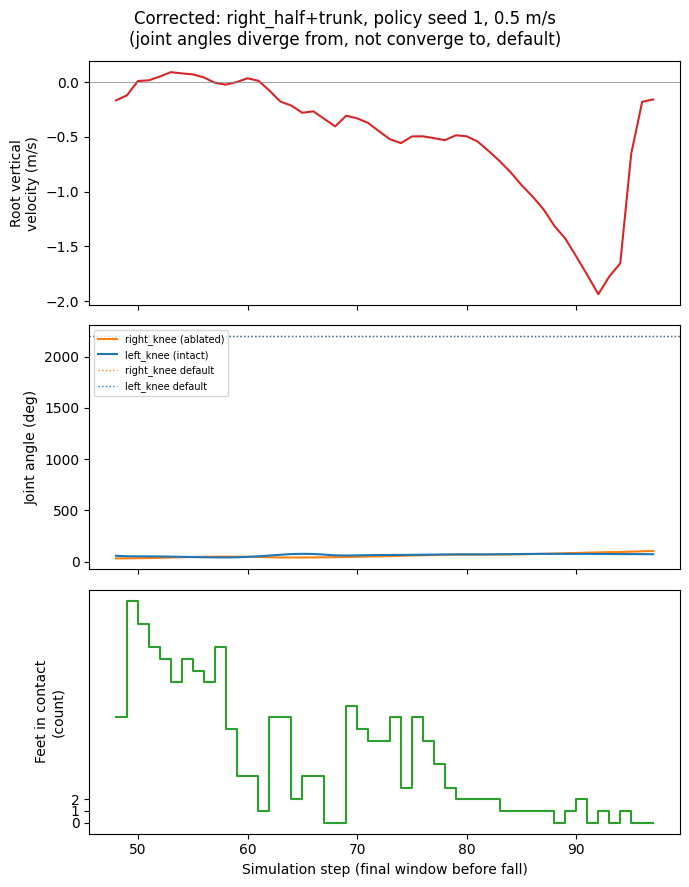


保存しました: figure4_corrected.png
この図が、§3.6訂正後のFigure 4の差し替え用データです。


In [39]:
import matplotlib.pyplot as plt

rep_result = corrected_mechanism_logs[("right_half+trunk(16)", 1)]
assert rep_result["fell"], "seed1が転倒していません。MECH_SEEDSにseed1が含まれているか確認してください。"

def _find_joint_idx(prefix):
    matches = [i for i, n in enumerate(JOINT_NAMES) if n.startswith(prefix)]
    if not matches:
        raise ValueError(
            f"'{prefix}' から始まる関節名が見つかりません。"
            f" JOINT_NAMESの実際の膝関節名を確認してください: "
            f"{[n for n in JOINT_NAMES if 'knee' in n]}"
        )
    return matches[0]

right_knee_idx = _find_joint_idx("right_knee")
left_knee_idx = _find_joint_idx("left_knee")

hist = rep_result["history"]
tt = rep_result["true_terminal"]

ts = [r["t"] for r in hist]
root_vz = [r["root_lin_vel_w"][2] for r in hist]
right_knee_deg = [np.degrees(r["joint_pos"][right_knee_idx]) for r in hist]
left_knee_deg = [np.degrees(r["joint_pos"][left_knee_idx]) for r in hist]
has_contact = hist[0].get("foot_contact_found") is not None
if has_contact:
    foot_contact_n = [int(np.sum(r["foot_contact_found"])) for r in hist]

# 転倒ステップ(最終ステップ)だけ、リセット汚染のない真の終端値で置き換える
if tt is not None:
    root_vz[-1] = tt["root_lin_vel_w"][2]
    right_knee_deg[-1] = np.degrees(tt["joint_pos"][right_knee_idx])
    left_knee_deg[-1] = np.degrees(tt["joint_pos"][left_knee_idx])
    if has_contact and tt.get("foot_contact_found") is not None:
        foot_contact_n[-1] = int(np.sum(tt["foot_contact_found"]))

    tracking_error_deg = np.degrees(np.abs(tt["joint_pos"] - tt["joint_pos_target"]))
    print(f"[修正後] 関節追従誤差(joint_pos vs joint_pos_target)の最大値: "
          f"{tracking_error_deg.max():.1f}度 "
          f"(最大の関節: {JOINT_NAMES[int(np.argmax(tracking_error_deg))]})")
    print(f"[修正後] 転倒直前の鉛直方向ルート速度: {tt['root_lin_vel_w'][2]:.2f} m/s")
    print(f"[修正後] 窓内の鉛直方向ルート速度の最小値: {min(root_vz):.2f} m/s")
    if tt.get("foot_contact_found") is not None:
        print(f"[修正後] 転倒時の足接地点数(左右): {tt['foot_contact_found']}")

n_panels = 3 if has_contact else 2
fig, axes = plt.subplots(n_panels, 1, figsize=(7, 3 * n_panels), sharex=True)

axes[0].plot(ts, root_vz, color="tab:red")
axes[0].set_ylabel("Root vertical\nvelocity (m/s)")
axes[0].axhline(0, color="gray", linewidth=0.5)

axes[1].plot(ts, right_knee_deg, label="right_knee (ablated)", color="tab:orange")
axes[1].plot(ts, left_knee_deg, label="left_knee (intact)", color="tab:blue")
axes[1].axhline(np.degrees(default_joint_pos_all[right_knee_idx]), color="tab:orange", linestyle=":", linewidth=1, label="right_knee default")
axes[1].axhline(np.degrees(default_joint_pos_all[left_knee_idx]), color="tab:blue", linestyle=":", linewidth=1, label="left_knee default")
axes[1].set_ylabel("Joint angle (deg)")
axes[1].legend(fontsize=7, loc="upper left")

if has_contact:
    axes[2].step(ts, foot_contact_n, where="post", color="tab:green")
    axes[2].set_ylabel("Feet in contact\n(count)")
    axes[2].set_yticks([0, 1, 2])

axes[-1].set_xlabel("Simulation step (final window before fall)")
fig.suptitle("Corrected: right_half+trunk, policy seed 1, 0.5 m/s\n(joint angles diverge from, not converge to, default)")
fig.tight_layout()
fig.savefig("figure4_corrected.png", dpi=200)
plt.show()

print("\n保存しました: figure4_corrected.png")
print("この図が、§3.6訂正後のFigure 4の差し替え用データです。")
